# Comprehensive Exploratory Data Analysis (EDA)
## Ad Click-Through Rate (CTR) Prediction

**Project Goal**: Predict the probability that a user will click on a displayed ad  
**Dataset**: Ad impression data with user, ad, contextual, and temporal features  
**Target Variable**: Click (0: No Click, 1: Click)  
**Date**: 2024-2025


---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Overview & Structure](#2-data-overview--structure)
3. [Data Quality Assessment](#3-data-quality-assessment)
4. [Target Variable Analysis](#4-target-variable-analysis)
5. [Univariate Analysis](#5-univariate-analysis)
6. [Bivariate Analysis with Target](#6-bivariate-analysis-with-target)
7. [Multivariate Analysis](#7-Multivariate-Analysis)
8. [Feature Relationships & Correlations](#8-feature-relationships--correlations)
9. [Categorical Features Deep Dive](#9-categorical-features-deep-dive)
10. [Temporal Analysis](#10-temporal-analysis)
11. [Statistical Insights & Tests](#11-statistical-insights--tests)
12. [Outlier Detection & Anomalies](#12-outlier-detection--anomalies)
13. [Feature Selection (Mutual Information, RF Importance, VIF)](#13-Feature-Selection-(Mutual-Information--RF--Importance--VIF))
14. [Data Leakage Detection Report](#14-data-leakage-detection-report)
15. [Summary & Recommendations](#14-summary--recommendations)


## 1. SETUP & DATA LOADING


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr
from sklearn.preprocessing import StandardScaler

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")
print(f"✓ Analysis started at: {datetime.now()}")


✓ All libraries imported successfully
✓ Analysis started at: 2026-06-17 19:13:51.499080


In [2]:
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
source_URL = "https://github.com/ajaychaudhary8104/Datasets/raw/refs/heads/main/CTR_raw_data.zip"

In [3]:
import os
from urllib import request

def download_file():
        '''
        Fetch data from the url
        '''

        try: 
            dataset_url = source_URL
            zip_download_dir = "artifacts/data_ingestion/CTR_raw_data.zip"
            os.makedirs("artifacts/data_ingestion", exist_ok=True)
            logger.info(f"Downloading data from {dataset_url} into file {zip_download_dir}")

            request.urlretrieve(dataset_url, zip_download_dir)

            logger.info(f"Downloaded data from {dataset_url} into file {zip_download_dir}")

        except Exception as e:
            raise e

In [4]:
import zipfile
def extract_zip_file():
        """
        zip_file_path: str
        Extracts the zip file into the data directory
        Function returns None
        """
        unzip_path = "artifacts/data_ingestion/unzipped_data"
        os.makedirs(unzip_path, exist_ok=True)
        with zipfile.ZipFile("artifacts/data_ingestion/CTR_raw_data.zip", 'r') as zip_ref:
            zip_ref.extractall(unzip_path)
        logger.info(f"Extracted zip file {zip_ref.filename} into dir {unzip_path}")

In [5]:
# -----------------------------
# download and extract data
# -----------------------------
download_file()
extract_zip_file()

INFO:__main__:Downloading data from https://github.com/ajaychaudhary8104/Datasets/raw/refs/heads/main/CTR_raw_data.zip into file artifacts/data_ingestion/CTR_raw_data.zip
INFO:__main__:Downloaded data from https://github.com/ajaychaudhary8104/Datasets/raw/refs/heads/main/CTR_raw_data.zip into file artifacts/data_ingestion/CTR_raw_data.zip
INFO:__main__:Extracted zip file artifacts/data_ingestion/CTR_raw_data.zip into dir artifacts/data_ingestion/unzipped_data


In [6]:
df = pd.read_csv("artifacts/data_ingestion/unzipped_data/CTR_raw_data.csv")
print("✓ Data loaded successfully")

✓ Data loaded successfully


---

## 2. DATA OVERVIEW & STRUCTURE


In [7]:
# =============================================================================
# DATASET OVERVIEW & STRUCTURE
# =============================================================================

print("=" * 80)
print("DATASET OVERVIEW & STRUCTURE")
print("=" * 80)

print("\n1. BASIC INFORMATION")
print("-" * 80)

print(f"Rows              : {df.shape[0]:,}")
print(f"Columns           : {df.shape[1]}")
print(f"Total Cells       : {df.shape[0] * df.shape[1]:,}")
print(
    f"Memory Usage      : "
    f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

print("\n2. SAMPLE RECORDS")
print("-" * 80)
display(df.head())

print("\n3. DATA TYPES")
print("-" * 80)
print(df.dtypes.value_counts())

print("\n4. FEATURE GROUPS")
print("-" * 80)

user_features = [
    "user_id",
    "user_age_group",
    "user_gender",
    "user_location_region",
    "user_device_type",
    "user_os",
    "user_browser",
    "user_interest_category"
]

user_history_features = [
    "user_historical_ctr",
    "user_total_impressions",
    "user_total_clicks",
    "user_avg_session_duration",
    "user_days_active",
    "user_conversion_rate",
    "previous_ad_clicks_today"
]

ad_features = [
    "ad_id",
    "advertiser_id",
    "ad_category",
    "ad_quality_score",
    "ad_creative_type",
    "ad_size",
    "ad_position"
]

advertiser_features = [
    "advertiser_historical_ctr",
    "advertiser_budget_utilization",
    "advertiser_days_active"
]

context_features = [
    "page_category",
    "page_quality_score",
    "page_dwell_time",
    "interest_match"
]

temporal_features = [
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_business_hours",
    "month",
    "seasonality"
]

engagement_features = [
    "time_since_last_impression",
    "time_since_last_click"
]

target_feature = ["click"]

feature_groups = {
    "User Features": user_features,
    "User History Features": user_history_features,
    "Ad Features": ad_features,
    "Advertiser Features": advertiser_features,
    "Context Features": context_features,
    "Temporal Features": temporal_features,
    "Engagement Features": engagement_features,
    "Target": target_feature
}

for group_name, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]

    print(
        f"{group_name:<30} "
        f"{len(existing_cols):>2} features"
    )

print("\n5. CATEGORICAL & NUMERICAL FEATURES")
print("-" * 80)

categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

if "click" in numerical_cols:
    numerical_cols.remove("click")

print(f"Categorical Features ({len(categorical_cols)}):")
print(categorical_cols)

print("\n")

print(f"Numerical Features ({len(numerical_cols)}):")
print(numerical_cols)

print("\n6. MISSING VALUE ANALYSIS")
print("-" * 80)

missing_df = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_df.columns = [
    "feature",
    "missing_count"
]

missing_df["missing_pct"] = (
    missing_df["missing_count"]
    / len(df)
    * 100
)

missing_df = missing_df[
    missing_df["missing_count"] > 0
].sort_values(
    "missing_count",
    ascending=False
)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✓ No missing values found")

print("\n7. TARGET DISTRIBUTION")
print("-" * 80)

positive_rate = df["click"].mean()

print(
    f"Positive Class (Click)     : "
    f"{df['click'].sum():,}"
)

print(
    f"Negative Class (No Click)  : "
    f"{len(df) - df['click'].sum():,}"
)

print(
    f"CTR / Positive Rate        : "
    f"{positive_rate:.2%}"
)

print("\n8. DATA QUALITY CHECK")
print("-" * 80)

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows     : {duplicate_rows:,}")
print(f"Unique Users       : {df['user_id'].nunique():,}")
print(f"Unique Ads         : {df['ad_id'].nunique():,}")
print(f"Unique Advertisers : {df['advertiser_id'].nunique():,}")

print("\n✓ Dataset overview completed successfully.")

DATASET OVERVIEW & STRUCTURE

1. BASIC INFORMATION
--------------------------------------------------------------------------------
Rows              : 100,000
Columns           : 40
Total Cells       : 4,000,000
Memory Usage      : 100.65 MB

2. SAMPLE RECORDS
--------------------------------------------------------------------------------


,user_id,user_age_group,user_gender,user_location_region,user_device_type,user_os,user_browser,user_interest_category,user_total_impressions,user_total_clicks,user_historical_ctr,user_avg_session_duration,user_days_active,user_conversion_rate,ad_id,advertiser_id,ad_category,ad_quality_score,ad_position,ad_creative_type,ad_size,advertiser_historical_ctr,advertiser_budget_utilization,advertiser_days_active,page_category,page_quality_score,page_dwell_time,hour_of_day,day_of_week,is_weekend,is_business_hours,time_since_last_impression,time_since_last_click,sequence_position,previous_ad_clicks_today,month,seasonality,interest_match,timestamp,click
0,12950,45-54,M,US-EAST,mobile,Windows,Safari,Health,90,2,0.022222,68.749489,30.508388,0.019084,8149,3995,Finance,2.046370,4,image,728x90,0.028571,0.285300,9.581211,News,6.827393,14.586082,0,4,0,0,1743.840359,4233.972408,1,1,3,off-peak,0,2024-03-01 00:00:00.000000000,0
1,40766,55+,M,ASIA,desktop,Windows,Chrome,Travel,109,2,0.018349,378.359432,38.833412,0.034403,5571,2250,Retail,6.890457,7,video,320x50,0.046859,0.956244,46.953910,Finance,9.610198,109.478763,0,4,0,0,7096.043403,5943.353920,2,1,3,off-peak,0,2024-03-01 00:01:44.545045450,1
2,43123,35-44,F,ASIA,desktop,Windows,Chrome,Entertainment,100,4,0.040000,63.794639,43.532123,0.048224,9220,2874,Entertainment,1.348516,9,text,160x600,0.036735,0.523031,6.793051,Sports,8.185187,22.921676,0,4,0,0,1576.959432,4704.017438,5,0,3,off-peak,1,2024-03-01 00:03:29.090090900,0
3,41493,55+,M,EU,tablet,MacOS,Safari,Finance,111,6,0.054054,146.417041,7.940553,0.011177,1862,468,Health,3.587395,3,image,728x90,0.073320,0.405594,101.206185,Sports,4.384435,61.119207,0,4,0,0,1028.874046,706.514539,1,1,3,off-peak,0,2024-03-01 00:05:13.635136351,0
4,15491,55+,M,US-WEST,desktop,Windows,Safari,Finance,120,5,0.041667,429.446753,31.173267,0.058093,5102,4703,Retail,8.343345,9,video,300x250,0.161386,0.347822,135.834170,Finance,4.190165,60.271677,0,4,0,0,3826.729674,6364.313637,9,2,3,off-peak,0,2024-03-01 00:06:58.180181801,0



3. DATA TYPES
--------------------------------------------------------------------------------
int64      15
object     13
float64    12
Name: count, dtype: int64

4. FEATURE GROUPS
--------------------------------------------------------------------------------
User Features                   8 features
User History Features           7 features
Ad Features                     7 features
Advertiser Features             3 features
Context Features                4 features
Temporal Features               6 features
Engagement Features             2 features
Target                          1 features

5. CATEGORICAL & NUMERICAL FEATURES
--------------------------------------------------------------------------------
Categorical Features (13):
['user_age_group', 'user_gender', 'user_location_region', 'user_device_type', 'user_os', 'user_browser', 'user_interest_category', 'ad_category', 'ad_creative_type', 'ad_size', 'page_category', 'seasonality', 'timestamp']


Numerical Features (26)

---

## 3. DATA QUALITY ASSESSMENT


In [8]:
# =============================================================================
# DATA QUALITY ASSESSMENT
# =============================================================================

print("\n" + "=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Missing Values
# -----------------------------------------------------------------------------

print("\n1. MISSING VALUES ANALYSIS")
print("-" * 80)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Count": missing_values.values,
    "Missing_Percentage": (
        missing_values.values / len(df) * 100
    ).round(2)
})

missing_df = missing_df[
    missing_df["Missing_Count"] > 0
].sort_values(
    "Missing_Percentage",
    ascending=False
)

if len(missing_df) == 0:
    print("✓ No missing values detected")
else:
    display(missing_df)

# -----------------------------------------------------------------------------
# 2. Duplicate Analysis
# -----------------------------------------------------------------------------

print("\n2. DUPLICATE ANALYSIS")
print("-" * 80)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count:,}")
print(
    f"Duplicate Rate : "
    f"{duplicate_count / len(df) * 100:.4f}%"
)

# -----------------------------------------------------------------------------
# 3. Data Type Summary
# -----------------------------------------------------------------------------

print("\n3. DATA TYPE SUMMARY")
print("-" * 80)

print(df.dtypes.value_counts())

# -----------------------------------------------------------------------------
# 4. Completeness Score
# -----------------------------------------------------------------------------

print("\n4. COMPLETENESS SCORE")
print("-" * 80)

total_cells = df.shape[0] * df.shape[1]

non_null_cells = df.count().sum()

completeness = (
    non_null_cells / total_cells
) * 100

print(f"Total Cells      : {total_cells:,}")
print(f"Non Null Cells   : {non_null_cells:,}")
print(f"Completeness     : {completeness:.2f}%")

# -----------------------------------------------------------------------------
# 5. Memory Usage
# -----------------------------------------------------------------------------

print("\n5. MEMORY USAGE")
print("-" * 80)

memory_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str),
    "Memory_MB": (
        df.memory_usage(deep=True, index=False).values
        / 1024**2
    )
})

memory_df = memory_df.sort_values(
    "Memory_MB",
    ascending=False
)

display(memory_df.head(15))

# -----------------------------------------------------------------------------
# 6. Business Rule Validation
# -----------------------------------------------------------------------------

print("\n6. BUSINESS RULE VALIDATION")
print("-" * 80)

checks = {}

# Historical CTR

checks["CTR Range"] = (
    (df["user_historical_ctr"] >= 0)
    &
    (df["user_historical_ctr"] <= 1)
).all()

# Conversion Rate

checks["Conversion Rate Range"] = (
    (df["user_conversion_rate"] >= 0)
    &
    (df["user_conversion_rate"] <= 1)
).all()

# Budget Utilization

checks["Budget Utilization Range"] = (
    (df["advertiser_budget_utilization"] >= 0)
    &
    (df["advertiser_budget_utilization"] <= 1)
).all()

# Interest Match

checks["Interest Match Range"] = (
    (df["interest_match"] >= 0)
    &
    (df["interest_match"] <= 1)
).all()

# Clicks <= Impressions

checks["Clicks <= Impressions"] = (
    df["user_total_clicks"]
    <=
    df["user_total_impressions"]
).all()

# Ad Position

checks["Ad Position Valid"] = (
    df["ad_position"] >= 1
).all()

# Session Duration

checks["Session Duration Positive"] = (
    df["user_avg_session_duration"] >= 0
).all()

# Dwell Time

checks["Page Dwell Time Positive"] = (
    df["page_dwell_time"] >= 0
).all()

# Time Since Click

checks["Time Since Click Positive"] = (
    df["time_since_last_click"] >= 0
).all()

# Time Since Impression

checks["Time Since Impression Positive"] = (
    df["time_since_last_impression"] >= 0
).all()

# Previous Clicks

checks["Previous Clicks Non-Negative"] = (
    df["previous_ad_clicks_today"] >= 0
).all()

# Target

checks["Binary Target"] = (
    set(df["click"].unique())
    <= {0, 1}
)

for name, result in checks.items():

    status = "✓ PASS" if result else "✗ FAIL"

    print(f"{name:<40} {status}")

# -----------------------------------------------------------------------------
# 7. Outlier Detection
# -----------------------------------------------------------------------------

print("\n7. OUTLIER ANALYSIS")
print("-" * 80)

numeric_cols = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

numeric_cols = [
    c for c in numeric_cols
    if c != "click"
]

outlier_summary = []

for col in numeric_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (df[col] < lower)
        |
        (df[col] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Outlier_%": round(
            outliers / len(df) * 100,
            2
        )
    })

outlier_df = pd.DataFrame(
    outlier_summary
).sort_values(
    "Outlier_%",
    ascending=False
)

display(outlier_df.head(10))

# -----------------------------------------------------------------------------
# 8. Target Analysis
# -----------------------------------------------------------------------------

print("\n8. TARGET DISTRIBUTION")
print("-" * 80)

click_rate = df["click"].mean()

print(f"Positive Class : {df['click'].sum():,}")
print(f"Negative Class : {(df['click']==0).sum():,}")
print(f"CTR            : {click_rate:.2%}")

imbalance_ratio = (
    (df["click"] == 0).sum()
    /
    max((df["click"] == 1).sum(), 1)
)

print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

# -----------------------------------------------------------------------------
# Final Assessment
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DATA QUALITY SCORECARD")
print("=" * 80)

quality_score = sum(checks.values()) / len(checks) * 100

print(f"Business Rule Score : {quality_score:.2f}%")

if quality_score >= 95:
    print("Assessment         : ✓ EXCELLENT")
elif quality_score >= 85:
    print("Assessment         : ✓ GOOD")
else:
    print("Assessment         : ⚠ NEEDS REVIEW")

print("\n✓ Data Quality Assessment Completed Successfully")


DATA QUALITY ASSESSMENT

1. MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------
✓ No missing values detected

2. DUPLICATE ANALYSIS
--------------------------------------------------------------------------------
Duplicate Rows : 0
Duplicate Rate : 0.0000%

3. DATA TYPE SUMMARY
--------------------------------------------------------------------------------
int64      15
object     13
float64    12
Name: count, dtype: int64

4. COMPLETENESS SCORE
--------------------------------------------------------------------------------
Total Cells      : 4,000,000
Non Null Cells   : 4,000,000
Completeness     : 100.00%

5. MEMORY USAGE
--------------------------------------------------------------------------------


,Column,Dtype,Memory_MB
timestamp,timestamp,object,8.201599
ad_category,ad_category,object,6.212413
user_interest_category,user_interest_category,object,6.211770
seasonality,seasonality,object,6.107456
ad_size,ad_size,object,6.055952
user_device_type,user_device_type,object,6.041470
page_category,page_category,object,5.994573
user_browser,user_browser,object,5.983893
user_os,user_os,object,5.960476
ad_creative_type,ad_creative_type,object,5.959881



6. BUSINESS RULE VALIDATION
--------------------------------------------------------------------------------
CTR Range                                ✓ PASS
Conversion Rate Range                    ✓ PASS
Budget Utilization Range                 ✓ PASS
Interest Match Range                     ✓ PASS
Clicks <= Impressions                    ✓ PASS
Ad Position Valid                        ✓ PASS
Session Duration Positive                ✓ PASS
Page Dwell Time Positive                 ✓ PASS
Time Since Click Positive                ✓ PASS
Time Since Impression Positive           ✓ PASS
Previous Clicks Non-Negative             ✓ PASS
Binary Target                            ✓ PASS

7. OUTLIER ANALYSIS
--------------------------------------------------------------------------------


,Feature,Outliers,Outlier_%
25,interest_match,14190,14.19
13,advertiser_days_active,5000,5.00
5,user_days_active,4881,4.88
21,time_since_last_click,4834,4.83
4,user_avg_session_duration,4790,4.79
20,time_since_last_impression,4786,4.79
15,page_dwell_time,4686,4.69
6,user_conversion_rate,2874,2.87
11,advertiser_historical_ctr,2746,2.75
3,user_historical_ctr,2653,2.65



8. TARGET DISTRIBUTION
--------------------------------------------------------------------------------
Positive Class : 32,893
Negative Class : 67,107
CTR            : 32.89%
Imbalance Ratio: 2.04:1

DATA QUALITY SCORECARD
Business Rule Score : 100.00%
Assessment         : ✓ EXCELLENT

✓ Data Quality Assessment Completed Successfully


---

## 4. TARGET VARIABLE ANALYSIS



TARGET VARIABLE ANALYSIS

1. CLICK DISTRIBUTION
--------------------------------------------------------------------------------
No Click (0) : 67,107 (67.11%)
Click (1)    : 32,893 (32.89%)

2. CLASS IMBALANCE ANALYSIS
--------------------------------------------------------------------------------
Negative : Positive Ratio  = 2.04:1
Scale Pos Weight (XGBoost) = 2.04
Assessment                 = Mildly Imbalanced

3. TARGET STATISTICS
--------------------------------------------------------------------------------
CTR (Mean)          : 0.3289
CTR Percentage      : 32.89%
Standard Deviation  : 0.4698
Variance            : 0.2207
Minimum             : 0
Maximum             : 1

4. BUSINESS INTERPRETATION
--------------------------------------------------------------------------------
High CTR (>10%)
Expected clicks per 1000 impressions ≈ 328.9


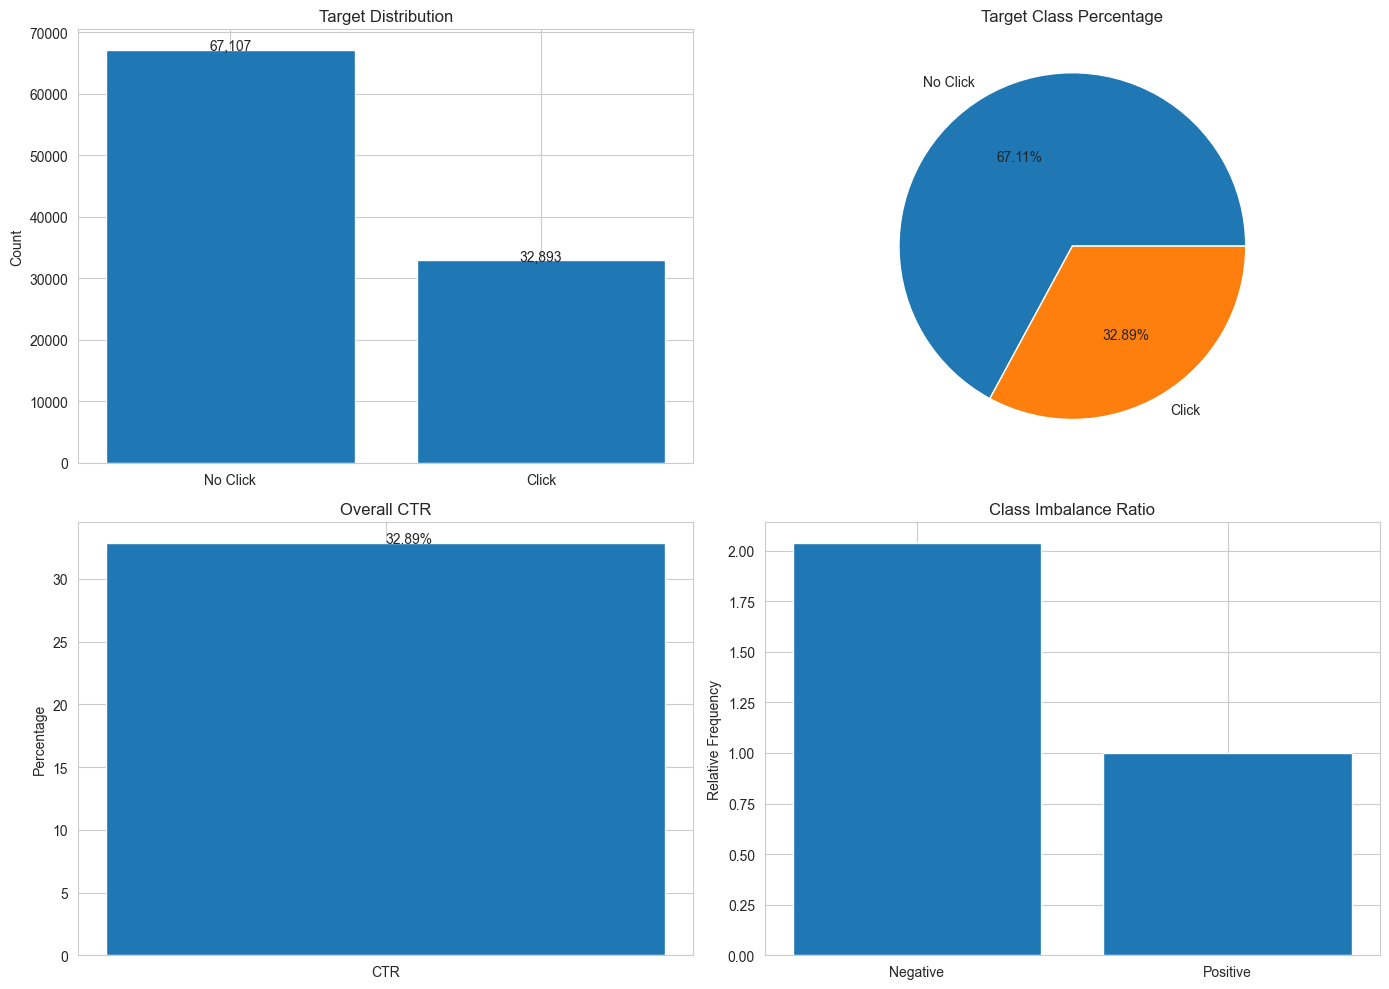


5. MODELING RECOMMENDATIONS
--------------------------------------------------------------------------------
✓ Use scale_pos_weight in XGBoost
✓ Perform threshold optimization
✓ Monitor Precision-Recall tradeoff
✓ Use calibration analysis
✓ Track business CTR lift metrics

✓ Target Variable Analysis Completed


In [9]:
# =============================================================================
# TARGET VARIABLE ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)

# -----------------------------------------------------------------------------
# Basic Distribution
# -----------------------------------------------------------------------------

click_counts = (
    df["click"]
    .value_counts()
    .sort_index()
)

click_pct = (
    df["click"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

negative_count = click_counts.get(0, 0)
positive_count = click_counts.get(1, 0)

negative_pct = click_pct.get(0, 0)
positive_pct = click_pct.get(1, 0)

print("\n1. CLICK DISTRIBUTION")
print("-" * 80)

print(f"No Click (0) : {negative_count:,} ({negative_pct:.2f}%)")
print(f"Click (1)    : {positive_count:,} ({positive_pct:.2f}%)")

# -----------------------------------------------------------------------------
# Class Imbalance
# -----------------------------------------------------------------------------

print("\n2. CLASS IMBALANCE ANALYSIS")
print("-" * 80)

if positive_count > 0:

    imbalance_ratio = negative_count / positive_count

    scale_pos_weight = imbalance_ratio

    print(f"Negative : Positive Ratio  = {imbalance_ratio:.2f}:1")
    print(f"Scale Pos Weight (XGBoost) = {scale_pos_weight:.2f}")

else:

    imbalance_ratio = np.inf

    print("No positive samples detected")

# Imbalance Assessment

if imbalance_ratio < 2:
    imbalance_status = "Balanced"
elif imbalance_ratio < 5:
    imbalance_status = "Mildly Imbalanced"
elif imbalance_ratio < 10:
    imbalance_status = "Moderately Imbalanced"
else:
    imbalance_status = "Highly Imbalanced"

print(f"Assessment                 = {imbalance_status}")

# -----------------------------------------------------------------------------
# Target Statistics
# -----------------------------------------------------------------------------

print("\n3. TARGET STATISTICS")
print("-" * 80)

ctr = df["click"].mean()

print(f"CTR (Mean)          : {ctr:.4f}")
print(f"CTR Percentage      : {ctr*100:.2f}%")
print(f"Standard Deviation  : {df['click'].std():.4f}")
print(f"Variance            : {df['click'].var():.4f}")
print(f"Minimum             : {df['click'].min()}")
print(f"Maximum             : {df['click'].max()}")

# -----------------------------------------------------------------------------
# Business Interpretation
# -----------------------------------------------------------------------------

print("\n4. BUSINESS INTERPRETATION")
print("-" * 80)

if ctr < 0.02:
    print("Very low CTR (<2%)")
elif ctr < 0.05:
    print("Low CTR (2-5%)")
elif ctr < 0.10:
    print("Average CTR (5-10%)")
else:
    print("High CTR (>10%)")

print(
    f"Expected clicks per 1000 impressions ≈ "
    f"{ctr*1000:.1f}"
)

# -----------------------------------------------------------------------------
# Visualization
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Count Plot

axes[0, 0].bar(
    ["No Click", "Click"],
    [negative_count, positive_count]
)

axes[0, 0].set_title("Target Distribution")
axes[0, 0].set_ylabel("Count")

for idx, value in enumerate(
    [negative_count, positive_count]
):
    axes[0, 0].text(
        idx,
        value,
        f"{value:,}",
        ha="center"
    )

# Pie Chart

axes[0, 1].pie(
    [negative_count, positive_count],
    labels=["No Click", "Click"],
    autopct="%1.2f%%"
)

axes[0, 1].set_title(
    "Target Class Percentage"
)

# CTR Visualization

axes[1, 0].bar(
    ["CTR"],
    [ctr * 100]
)

axes[1, 0].set_ylabel("Percentage")
axes[1, 0].set_title("Overall CTR")

axes[1, 0].text(
    0,
    ctr * 100,
    f"{ctr*100:.2f}%"
)

# Imbalance Ratio

axes[1, 1].bar(
    ["Negative", "Positive"],
    [imbalance_ratio, 1]
)

axes[1, 1].set_title(
    "Class Imbalance Ratio"
)

axes[1, 1].set_ylabel(
    "Relative Frequency"
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Modeling Recommendations
# -----------------------------------------------------------------------------

print("\n5. MODELING RECOMMENDATIONS")
print("-" * 80)

recommendations = []

if imbalance_ratio > 2:
    recommendations.append(
        "Use scale_pos_weight in XGBoost"
    )

if imbalance_ratio > 5:
    recommendations.append(
        "Evaluate PR-AUC in addition to ROC-AUC"
    )

if imbalance_ratio > 10:
    recommendations.append(
        "Consider SMOTE or undersampling experiments"
    )

recommendations.extend([
    "Perform threshold optimization",
    "Monitor Precision-Recall tradeoff",
    "Use calibration analysis",
    "Track business CTR lift metrics"
])

for rec in recommendations:
    print(f"✓ {rec}")

print("\n✓ Target Variable Analysis Completed")

---

## 5. UNIVARIATE ANALYSIS



UNIVARIATE ANALYSIS

NUMERICAL FEATURES SUMMARY
--------------------------------------------------------------------------------
                                 dtype  missing_count  missing_pct  \
user_id                          int64              0          0.0   
user_total_impressions           int64              0          0.0   
user_total_clicks                int64              0          0.0   
user_historical_ctr            float64              0          0.0   
user_avg_session_duration      float64              0          0.0   
user_days_active               float64              0          0.0   
user_conversion_rate           float64              0          0.0   
ad_id                            int64              0          0.0   
advertiser_id                    int64              0          0.0   
ad_quality_score               float64              0          0.0   
ad_position                      int64              0          0.0   
advertiser_historical_ctr     

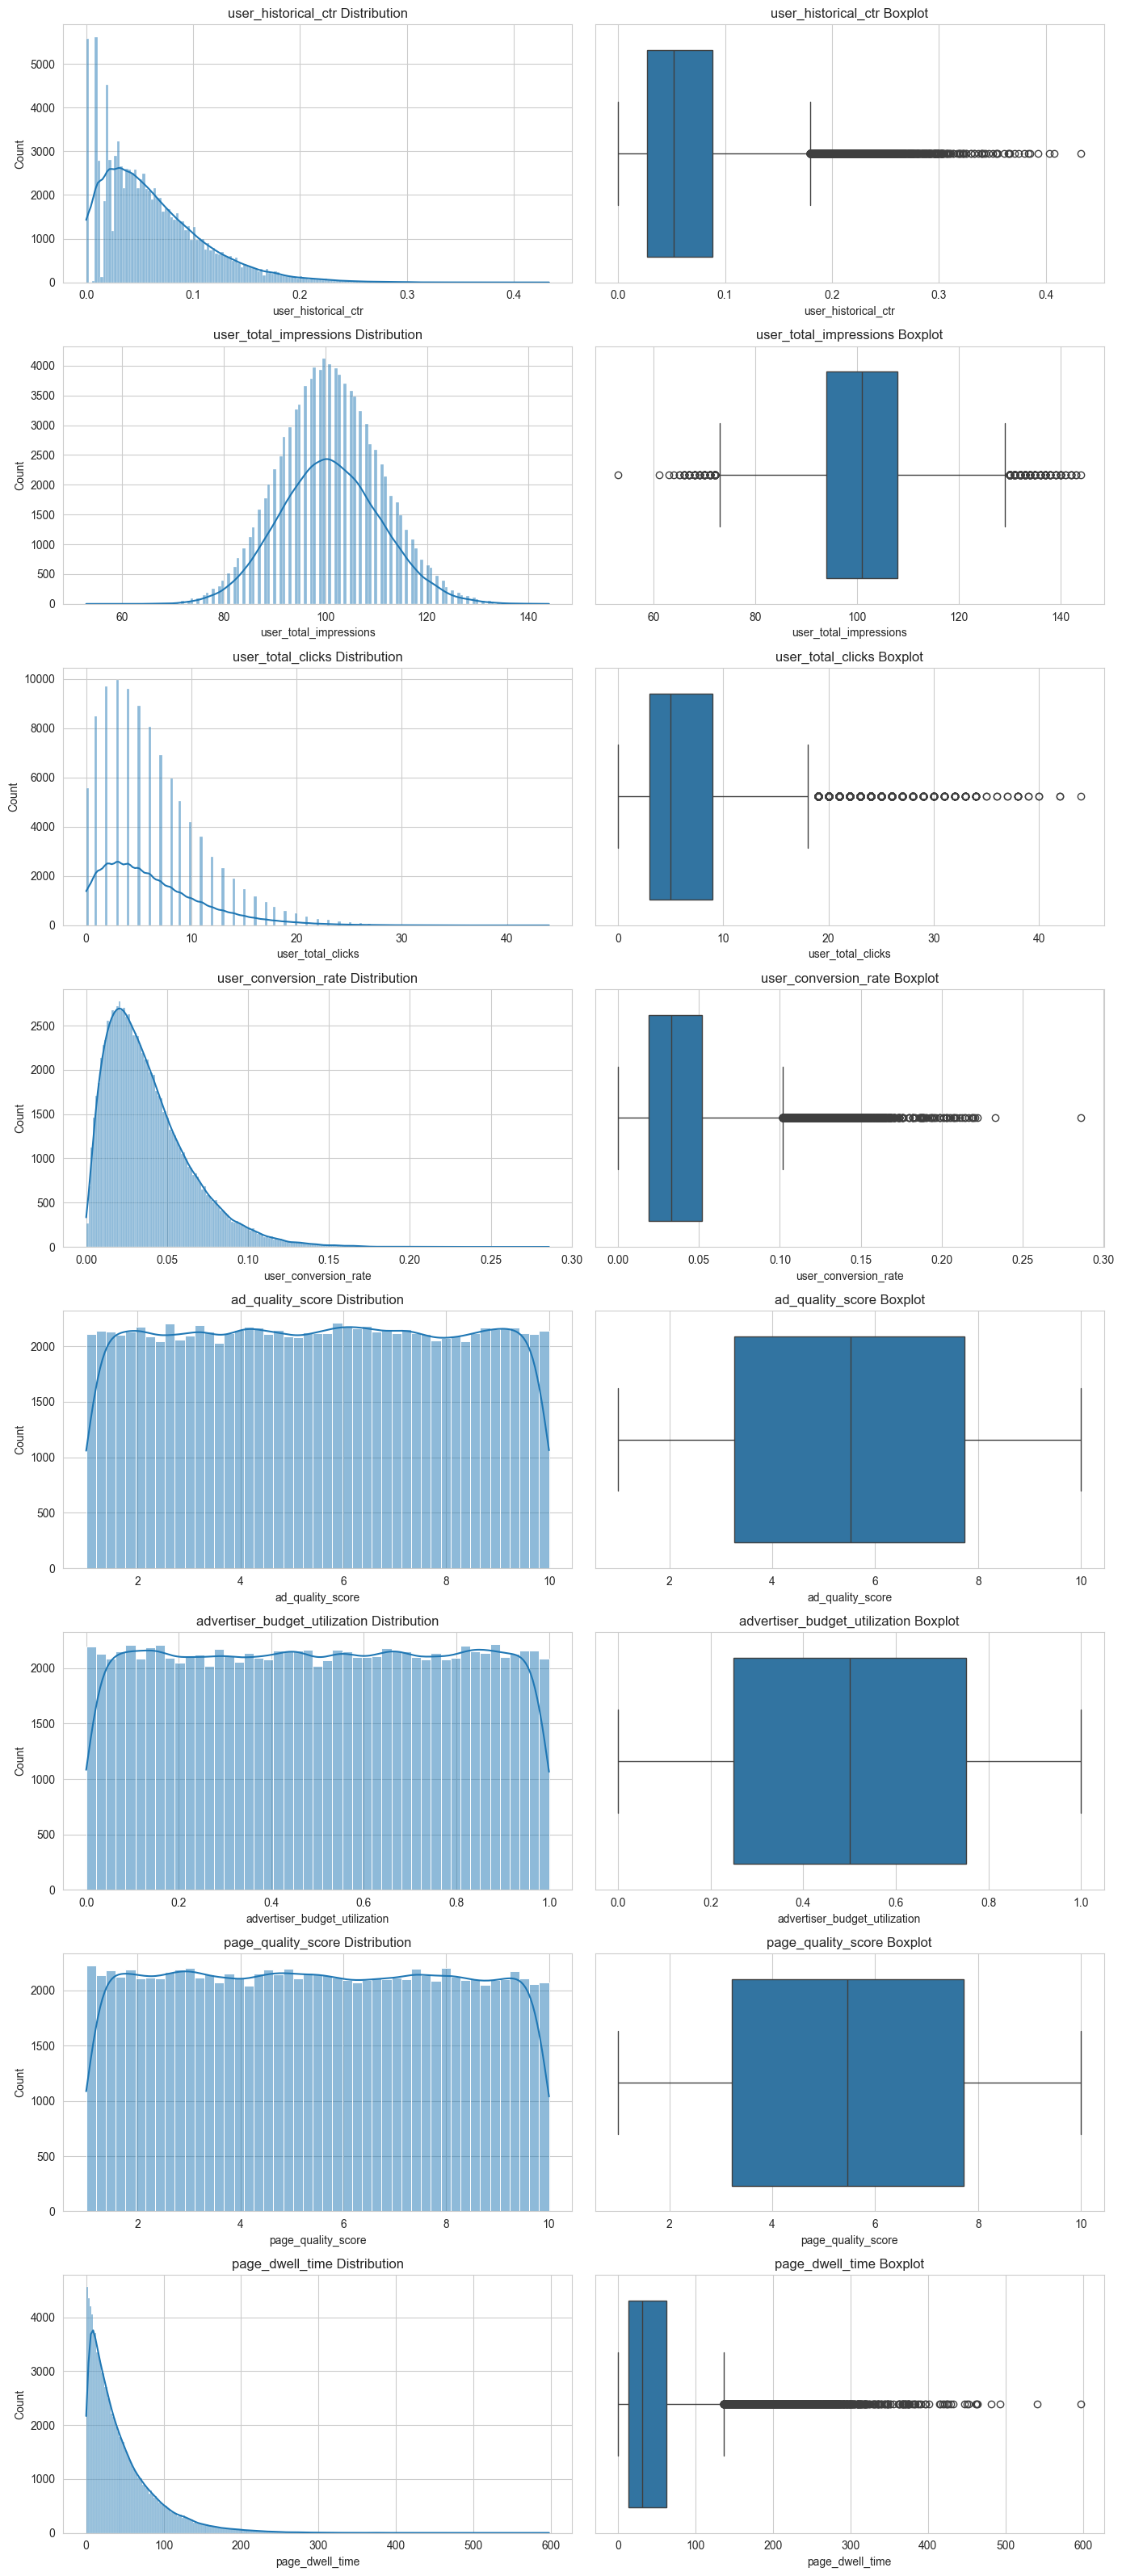


CATEGORICAL FEATURE ANALYSIS
                   feature  missing_pct  unique_values
0           user_age_group          0.0              5
1              user_gender          0.0              3
2     user_location_region          0.0              4
3         user_device_type          0.0              3
4                  user_os          0.0              4
5             user_browser          0.0              4
6   user_interest_category          0.0              7
7              ad_category          0.0              7
8         ad_creative_type          0.0              4
9                  ad_size          0.0              4
10           page_category          0.0              7
11             seasonality          0.0              2
12               timestamp          0.0         100000


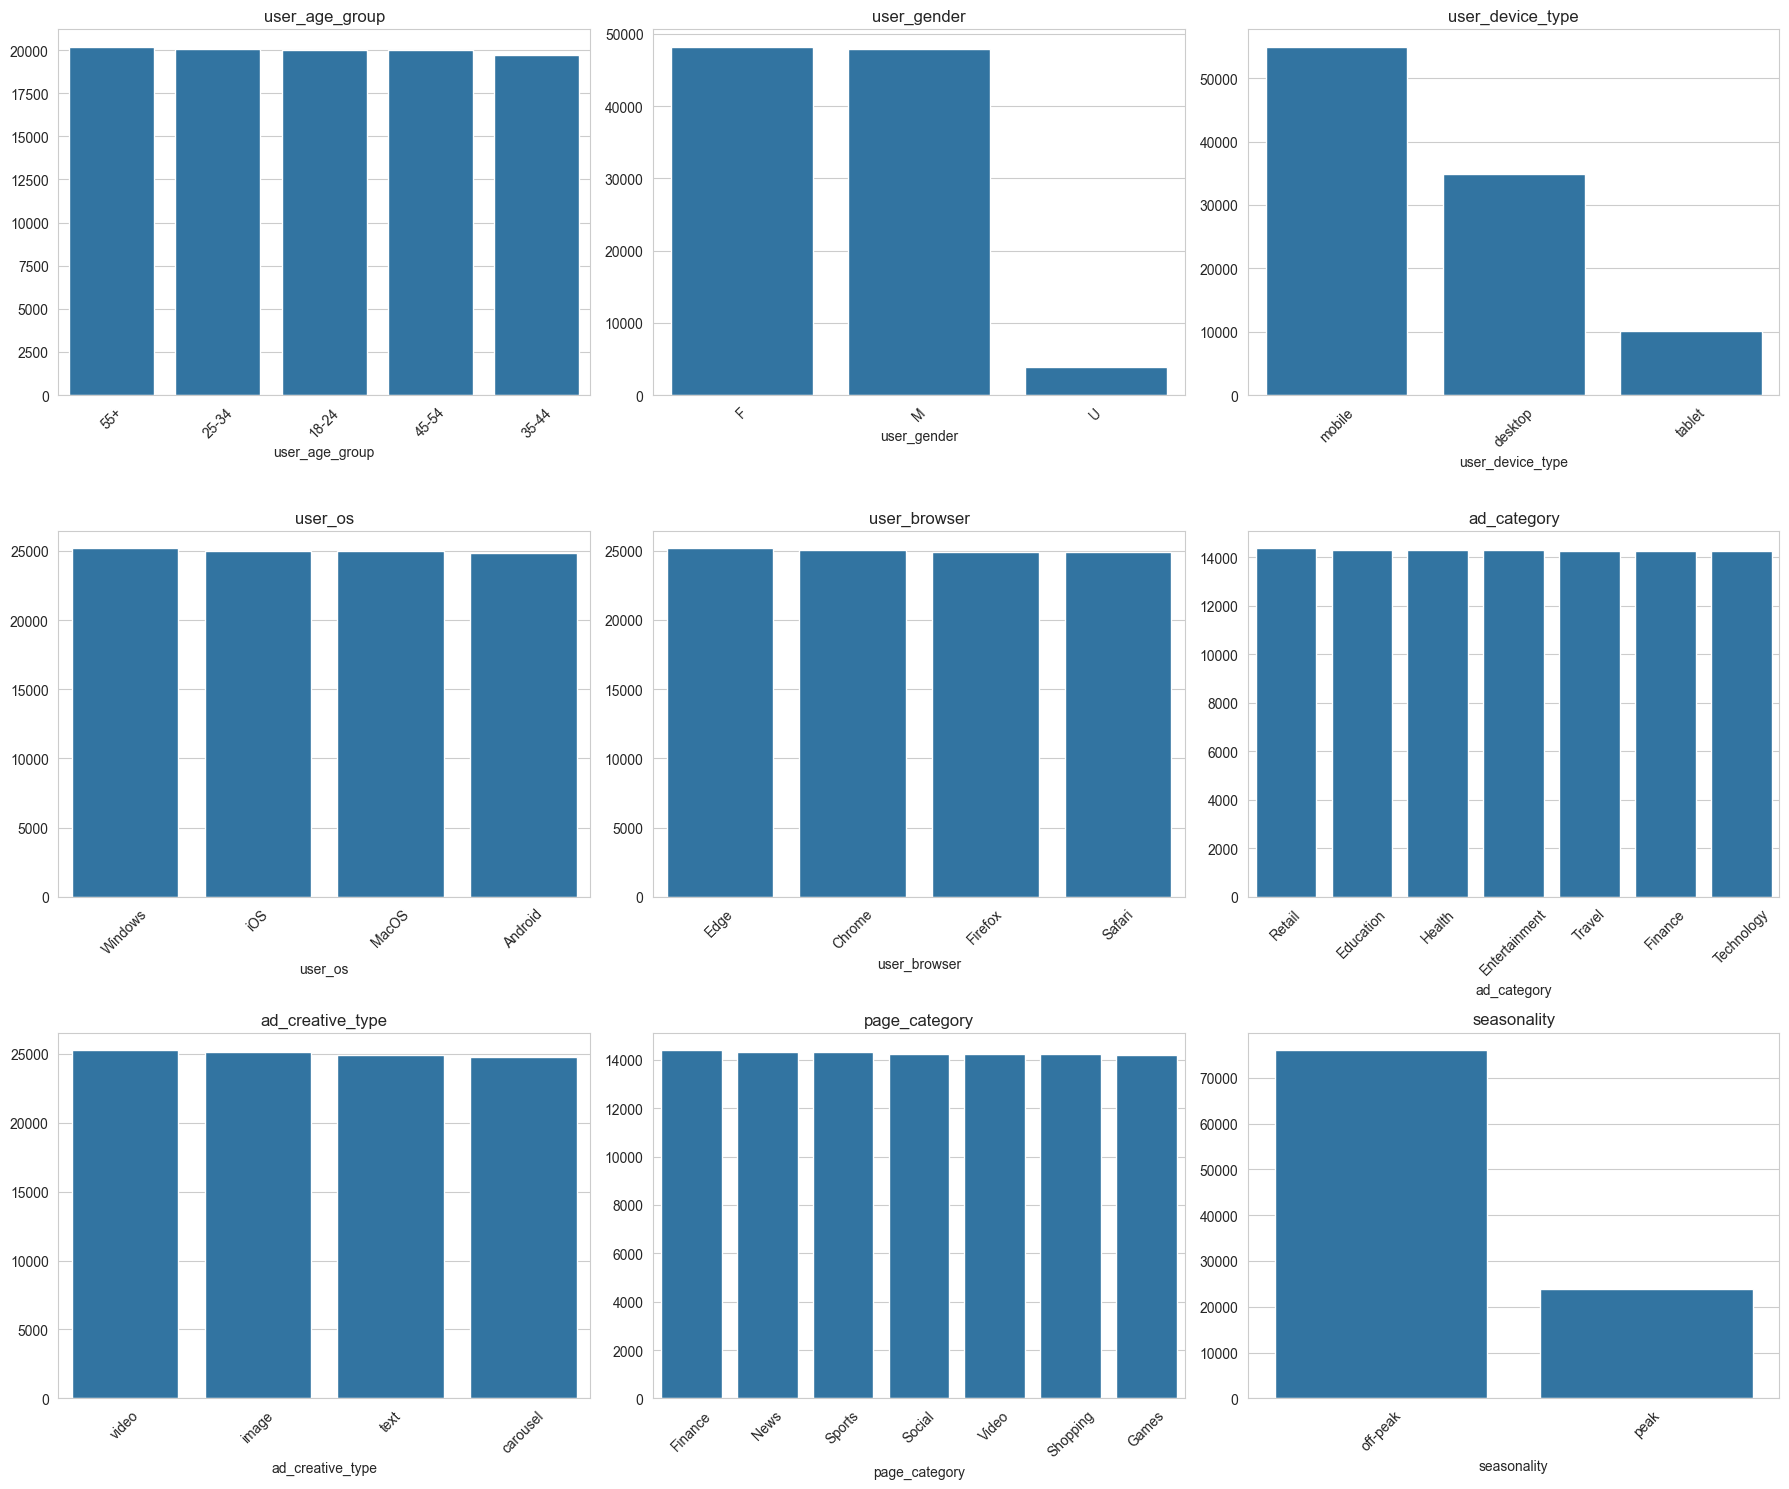


LOW VARIANCE FEATURES
--------------------------------------------------------------------------------
user_historical_ctr                      Variance=0.002333
user_conversion_rate                     Variance=0.000699
advertiser_historical_ctr                Variance=0.001088

HIGH CARDINALITY FEATURES
--------------------------------------------------------------------------------
timestamp                                Unique=100000

UNIVARIATE ANALYSIS SUMMARY

Total Numerical Features      : 26
Total Categorical Features    : 13

Features With Outliers        : 11
High Cardinality Features     : 1

Most Skewed Feature:
interest_match

Most Variable Feature:
user_id

Least Variable Feature:
user_conversion_rate


✓ Univariate Analysis Completed Successfully


In [10]:
# =============================================================================
# UNIVARIATE ANALYSIS
# =============================================================================

print("\n" + "="*100)
print("UNIVARIATE ANALYSIS")
print("="*100)

# =============================================================================
# NUMERICAL FEATURES
# =============================================================================

numerical_cols = df.select_dtypes(
    include=["int64", "float64","int32","float32"]
).drop(
    columns=["click"],
    errors="ignore"
).columns.tolist()

print("\nNUMERICAL FEATURES SUMMARY")
print("-"*80)

summary_stats = pd.DataFrame({
    "dtype": df[numerical_cols].dtypes,
    "missing_count": df[numerical_cols].isnull().sum(),
    "missing_pct": round(df[numerical_cols].isnull().mean()*100,2),
    "unique_values": df[numerical_cols].nunique(),
    "mean": df[numerical_cols].mean(),
    "median": df[numerical_cols].median(),
    "std": df[numerical_cols].std(),
    "min": df[numerical_cols].min(),
    "max": df[numerical_cols].max(),
    "skewness": df[numerical_cols].skew(),
    "kurtosis": df[numerical_cols].kurtosis()
})

print(summary_stats.round(4))

# =============================================================================
# OUTLIER ANALYSIS
# =============================================================================

print("\nOUTLIER ANALYSIS")
print("-"*80)

outlier_results = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_results.append({
        "feature": col,
        "outliers": outliers,
        "outlier_pct": round(outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(
    outlier_results
).sort_values(
    "outlier_pct",
    ascending=False
)

print(outlier_df)

# =============================================================================
# DISTRIBUTION ANALYSIS
# =============================================================================

print("\nCREATING NUMERICAL DISTRIBUTION PLOTS...")

top_features = [
    "user_historical_ctr",
    "user_total_impressions",
    "user_total_clicks",
    "user_conversion_rate",
    "ad_quality_score",
    "advertiser_budget_utilization",
    "page_quality_score",
    "page_dwell_time"
]

fig, axes = plt.subplots(
    len(top_features),
    2,
    figsize=(14, 4*len(top_features))
)

for idx, feature in enumerate(top_features):

    # Histogram

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[idx,0]
    )

    axes[idx,0].set_title(
        f"{feature} Distribution"
    )

    # Boxplot

    sns.boxplot(
        x=df[feature],
        ax=axes[idx,1]
    )

    axes[idx,1].set_title(
        f"{feature} Boxplot"
    )

plt.tight_layout()
plt.savefig(
    "numerical_feature_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =============================================================================
# CATEGORICAL FEATURES
# =============================================================================

print("\n" + "="*100)
print("CATEGORICAL FEATURE ANALYSIS")
print("="*100)

categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

cat_summary = pd.DataFrame({
    "feature": categorical_cols,
    "missing_pct": [
        round(df[col].isnull().mean()*100,2)
        for col in categorical_cols
    ],
    "unique_values": [
        df[col].nunique()
        for col in categorical_cols
    ]
})

print(cat_summary)

# =============================================================================
# CATEGORY DISTRIBUTIONS
# =============================================================================

plot_features = [
    "user_age_group",
    "user_gender",
    "user_device_type",
    "user_os",
    "user_browser",
    "ad_category",
    "ad_creative_type",
    "page_category",
    "seasonality"
]

rows = int(np.ceil(len(plot_features)/3))

fig, axes = plt.subplots(
    rows,
    3,
    figsize=(18, rows*5)
)

axes = axes.flatten()

for idx, feature in enumerate(plot_features):

    value_counts = (
        df[feature]
        .value_counts()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        ax=axes[idx]
    )

    axes[idx].set_title(feature)
    axes[idx].tick_params(
        axis='x',
        rotation=45
    )

for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(
    "categorical_feature_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =============================================================================
# LOW VARIANCE FEATURES
# =============================================================================

print("\nLOW VARIANCE FEATURES")
print("-"*80)

for col in numerical_cols:

    variance = df[col].var()

    if variance < 0.01:
        print(
            f"{col:<40} Variance={variance:.6f}"
        )

# =============================================================================
# HIGH CARDINALITY FEATURES
# =============================================================================

print("\nHIGH CARDINALITY FEATURES")
print("-"*80)

for col in categorical_cols:

    cardinality = df[col].nunique()

    if cardinality > 20:
        print(
            f"{col:<40} Unique={cardinality}"
        )

# =============================================================================
# SUMMARY REPORT
# =============================================================================

print("\n" + "="*100)
print("UNIVARIATE ANALYSIS SUMMARY")
print("="*100)

print(f"""
Total Numerical Features      : {len(numerical_cols)}
Total Categorical Features    : {len(categorical_cols)}

Features With Outliers        : {(outlier_df['outlier_pct'] > 1).sum()}
High Cardinality Features     : {sum(df[c].nunique() > 20 for c in categorical_cols)}

Most Skewed Feature:
{summary_stats['skewness'].abs().idxmax()}

Most Variable Feature:
{summary_stats['std'].idxmax()}

Least Variable Feature:
{summary_stats['std'].idxmin()}
""")

print("\n✓ Univariate Analysis Completed Successfully")

---

## 6. BIVARIATE ANALYSIS WITH TARGET



BIVARIATE ANALYSIS

NUMERICAL FEATURES VS TARGET
----------------------------------------------------------------------------------------------------
                          Feature  Correlation  P_Value  Click_Mean  \
9                ad_quality_score       0.2095   0.0000      6.2802   
3             user_historical_ctr       0.1713   0.0000      0.0742   
2               user_total_clicks       0.1702   0.0000      7.5000   
14             page_quality_score       0.1605   0.0000      6.0740   
10                    ad_position      -0.0851   0.0000      5.1487   
11      advertiser_historical_ctr       0.0815   0.0000      0.0513   
25                 interest_match       0.0718   0.0000      0.1777   
19              is_business_hours       0.0626   0.0000      0.4607   
24                          month       0.0468   0.0000      4.5539   
23       previous_ad_clicks_today       0.0406   0.0000      1.0569   
16                    hour_of_day       0.0153   0.0000     11.6515 

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

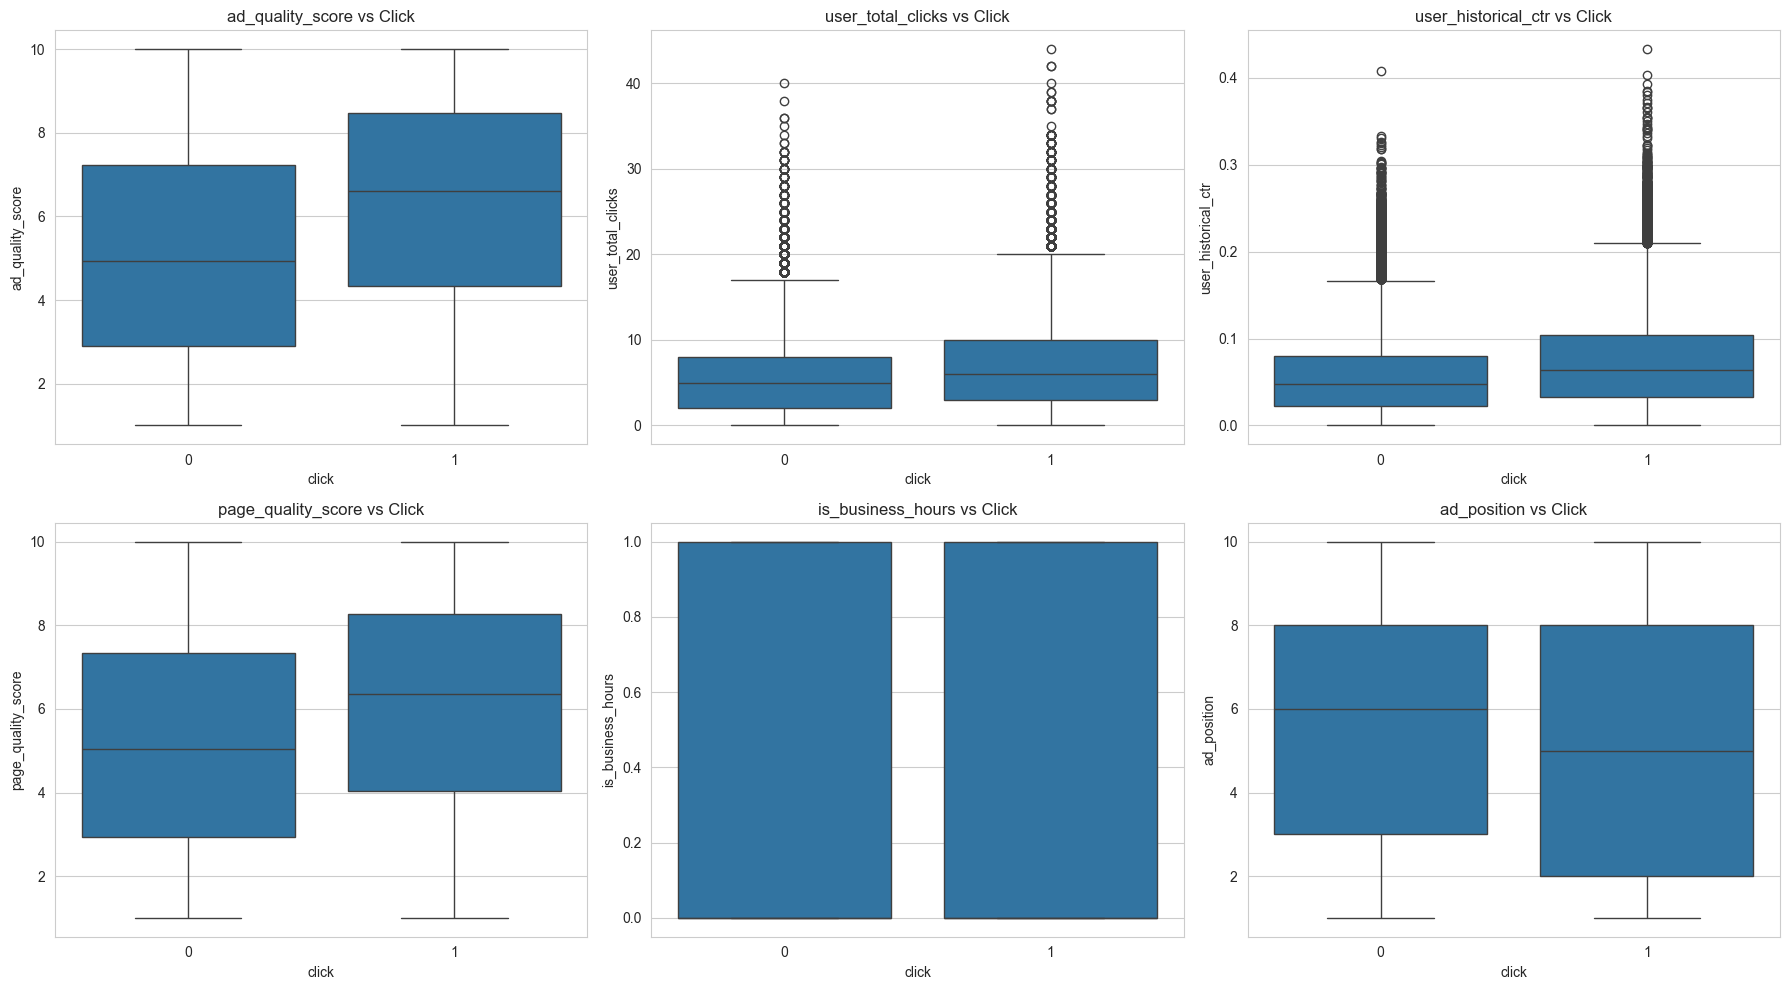


CATEGORICAL FEATURES VS TARGET
                   Feature         Chi2  P_Value  Max_CTR_Lift
12               timestamp  100000.0000   0.4985        3.0402
11             seasonality     329.3743   0.0000        1.1461
3         user_device_type     201.7916   0.0000        1.0560
7              ad_category      14.5189   0.0243        1.0222
10           page_category       9.4670   0.1490        1.0198
6   user_interest_category       7.5447   0.2734        1.0246
0           user_age_group       4.4302   0.3509        1.0119
5             user_browser       2.6005   0.4574        1.0114
9                  ad_size       2.0376   0.5646        1.0111
4                  user_os       1.7169   0.6332        1.0074
1              user_gender       1.1209   0.5709        1.0085
2     user_location_region       0.9073   0.8237        1.0052
8         ad_creative_type       0.8096   0.8472        1.0066


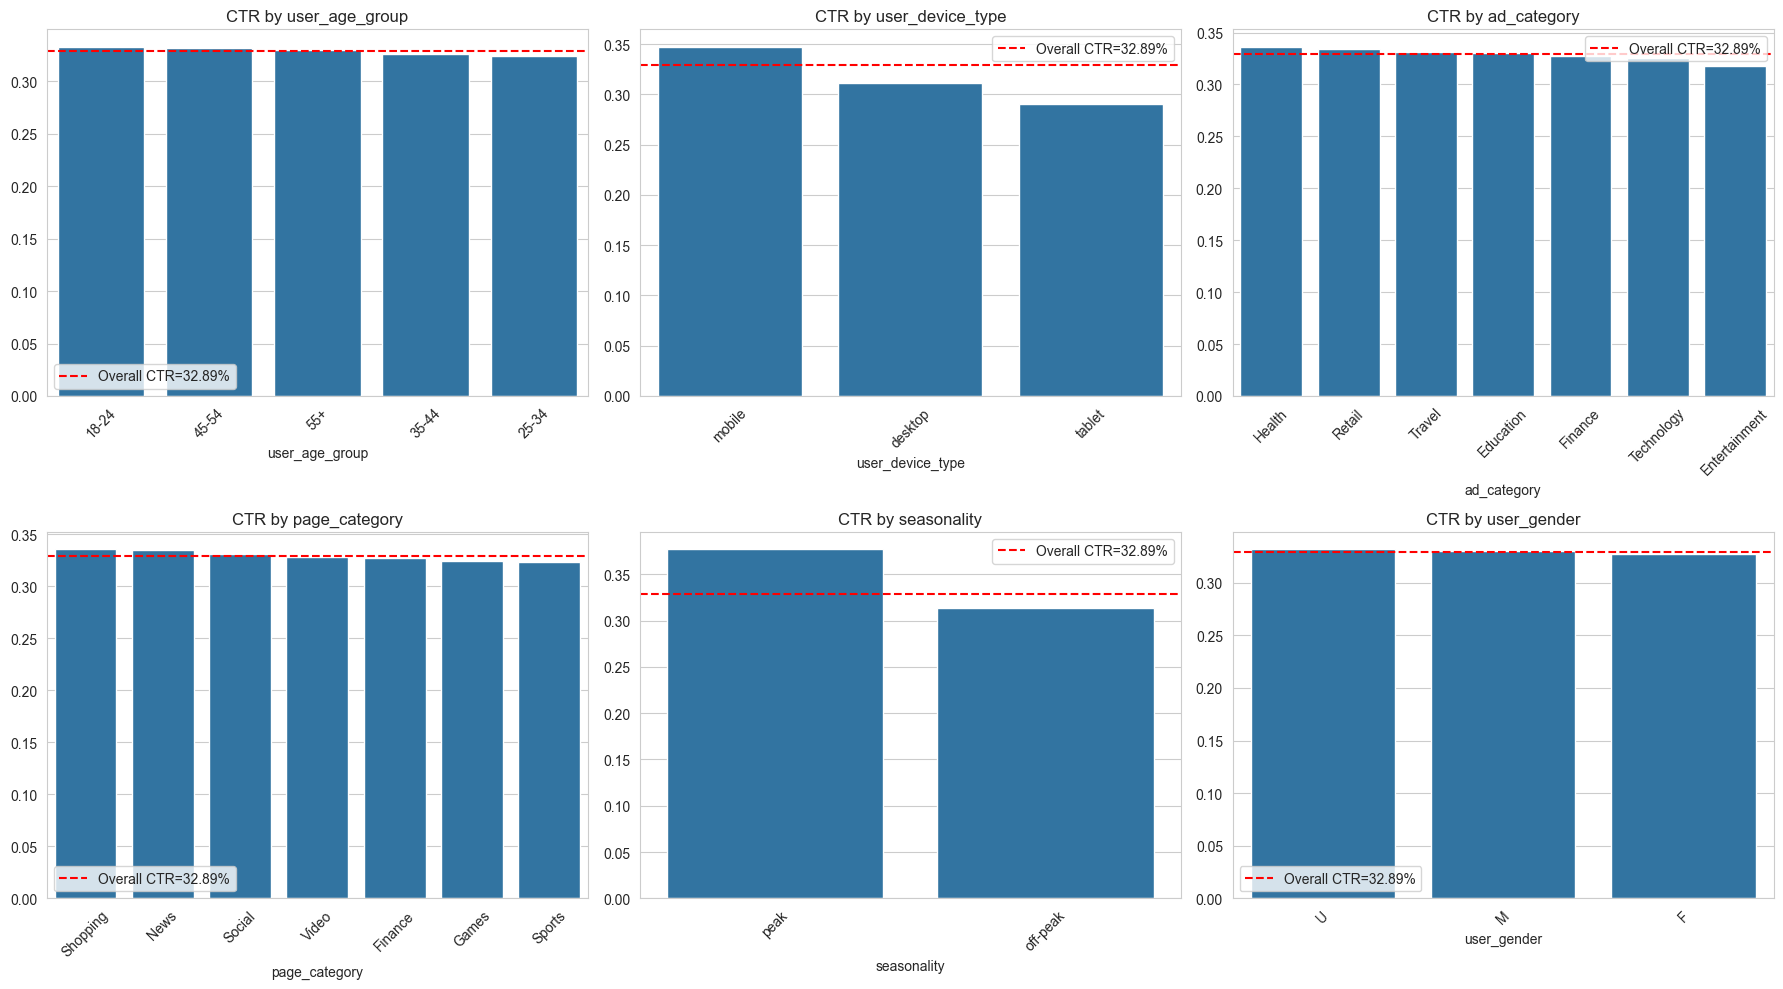


CTR LIFT ANALYSIS
----------------------------------------------------------------------------------------------------
            Feature Best Segment     CTR    Lift
4       seasonality         peak  0.3770  1.1461
1  user_device_type       mobile  0.3474  1.0560
2       ad_category       Health  0.3362  1.0222
3     page_category     Shopping  0.3354  1.0198
0    user_age_group        18-24  0.3329  1.0119
5       user_gender            U  0.3317  1.0085

BIVARIATE ANALYSIS SUMMARY

Top Numerical Predictor:
ad_quality_score

Highest Mutual Information:
0.0248

Strongest Categorical Predictor:
timestamp

Highest Chi-Square:
100000.00

Overall CTR:
32.89%

Most Valuable Segment:
peak

CTR Lift:
1.15x


✓ Bivariate Analysis Completed Successfully


In [11]:
# =============================================================================
# BIVARIATE ANALYSIS
# =============================================================================

from scipy.stats import ttest_ind, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

print("\n" + "="*100)
print("BIVARIATE ANALYSIS")
print("="*100)

# =============================================================================
# NUMERICAL FEATURES VS TARGET
# =============================================================================

print("\nNUMERICAL FEATURES VS TARGET")
print("-"*100)

numerical_cols = df.select_dtypes(
    include=["int64","float64","int32","float32"]
).drop(
    columns=["click"],
    errors="ignore"
).columns.tolist()

bivariate_results = []

for col in numerical_cols:

    click_group = df[df["click"] == 1][col]
    no_click_group = df[df["click"] == 0][col]

    corr = df[col].corr(df["click"])

    t_stat, p_value = ttest_ind(
        click_group,
        no_click_group,
        equal_var=False
    )

    bivariate_results.append({
        "Feature": col,
        "Correlation": corr,
        "P_Value": p_value,
        "Click_Mean": click_group.mean(),
        "No_Click_Mean": no_click_group.mean()
    })

bivariate_df = pd.DataFrame(
    bivariate_results
).sort_values(
    by="Correlation",
    key=np.abs,
    ascending=False
)

print(bivariate_df.round(4))

# =============================================================================
# MUTUAL INFORMATION
# =============================================================================

print("\nMUTUAL INFORMATION SCORES")
print("-"*100)

X_temp = df[numerical_cols].fillna(0)

mi_scores = mutual_info_classif(
    X_temp,
    df["click"],
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": numerical_cols,
    "MI Score": mi_scores
}).sort_values(
    "MI Score",
    ascending=False
)

print(mi_df.round(4))

# =============================================================================
# TOP FEATURES
# =============================================================================

top_numeric_features = mi_df.head(6)["Feature"].tolist()

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for idx, feature in enumerate(top_numeric_features):

    sns.boxplot(
        data=df,
        x="click",
        y=feature,
        ax=axes[idx]
    )

    axes[idx].set_title(
        f"{feature} vs Click"
    )

plt.tight_layout()
plt.savefig(
    "top_numeric_vs_target.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =============================================================================
# CATEGORICAL FEATURES VS TARGET
# =============================================================================

print("\n" + "="*100)
print("CATEGORICAL FEATURES VS TARGET")
print("="*100)

categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

cat_results = []

for col in categorical_cols:

    contingency = pd.crosstab(
        df[col],
        df["click"]
    )

    chi2, p_value, _, _ = chi2_contingency(
        contingency
    )

    ctr_by_category = (
        df.groupby(col)["click"]
        .mean()
        .sort_values(ascending=False)
    )

    ctr_lift = (
        ctr_by_category.max()
        /
        df["click"].mean()
    )

    cat_results.append({
        "Feature": col,
        "Chi2": chi2,
        "P_Value": p_value,
        "Max_CTR_Lift": ctr_lift
    })

cat_results_df = pd.DataFrame(
    cat_results
).sort_values(
    "Chi2",
    ascending=False
)

print(cat_results_df.round(4))

# =============================================================================
# CTR BY CATEGORY
# =============================================================================

important_cats = [
    "user_age_group",
    "user_device_type",
    "ad_category",
    "page_category",
    "seasonality",
    "user_gender"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

overall_ctr = df["click"].mean()

for idx, feature in enumerate(important_cats):

    ctr = (
        df.groupby(feature)["click"]
        .mean()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=ctr.index,
        y=ctr.values,
        ax=axes[idx]
    )

    axes[idx].axhline(
        overall_ctr,
        color="red",
        linestyle="--",
        label=f"Overall CTR={overall_ctr:.2%}"
    )

    axes[idx].set_title(
        f"CTR by {feature}"
    )

    axes[idx].tick_params(
        axis="x",
        rotation=45
    )

    axes[idx].legend()

plt.tight_layout()
plt.savefig(
    "categorical_ctr_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =============================================================================
# CTR LIFT ANALYSIS
# =============================================================================

print("\nCTR LIFT ANALYSIS")
print("-"*100)

lift_results = []

for feature in important_cats:

    ctr_table = (
        df.groupby(feature)["click"]
        .mean()
        .reset_index()
    )

    ctr_table["lift"] = (
        ctr_table["click"]
        /
        overall_ctr
    )

    top_segment = ctr_table.sort_values(
        "lift",
        ascending=False
    ).iloc[0]

    lift_results.append({
        "Feature": feature,
        "Best Segment": top_segment[feature],
        "CTR": top_segment["click"],
        "Lift": top_segment["lift"]
    })

lift_df = pd.DataFrame(
    lift_results
).sort_values(
    "Lift",
    ascending=False
)

print(lift_df.round(4))

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "="*100)
print("BIVARIATE ANALYSIS SUMMARY")
print("="*100)

print(f"""
Top Numerical Predictor:
{mi_df.iloc[0]['Feature']}

Highest Mutual Information:
{mi_df.iloc[0]['MI Score']:.4f}

Strongest Categorical Predictor:
{cat_results_df.iloc[0]['Feature']}

Highest Chi-Square:
{cat_results_df.iloc[0]['Chi2']:.2f}

Overall CTR:
{overall_ctr:.2%}

Most Valuable Segment:
{lift_df.iloc[0]['Best Segment']}

CTR Lift:
{lift_df.iloc[0]['Lift']:.2f}x
""")

print("\n✓ Bivariate Analysis Completed Successfully")

---

## 7. Multivariate Analysis


MULTIVARIATE ANALYSIS

1. CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Highly Correlated Features (>0.75):
user_historical_ctr                      user_total_clicks                        Corr=0.9872
is_weekend                               day_of_week                              Corr=0.7875


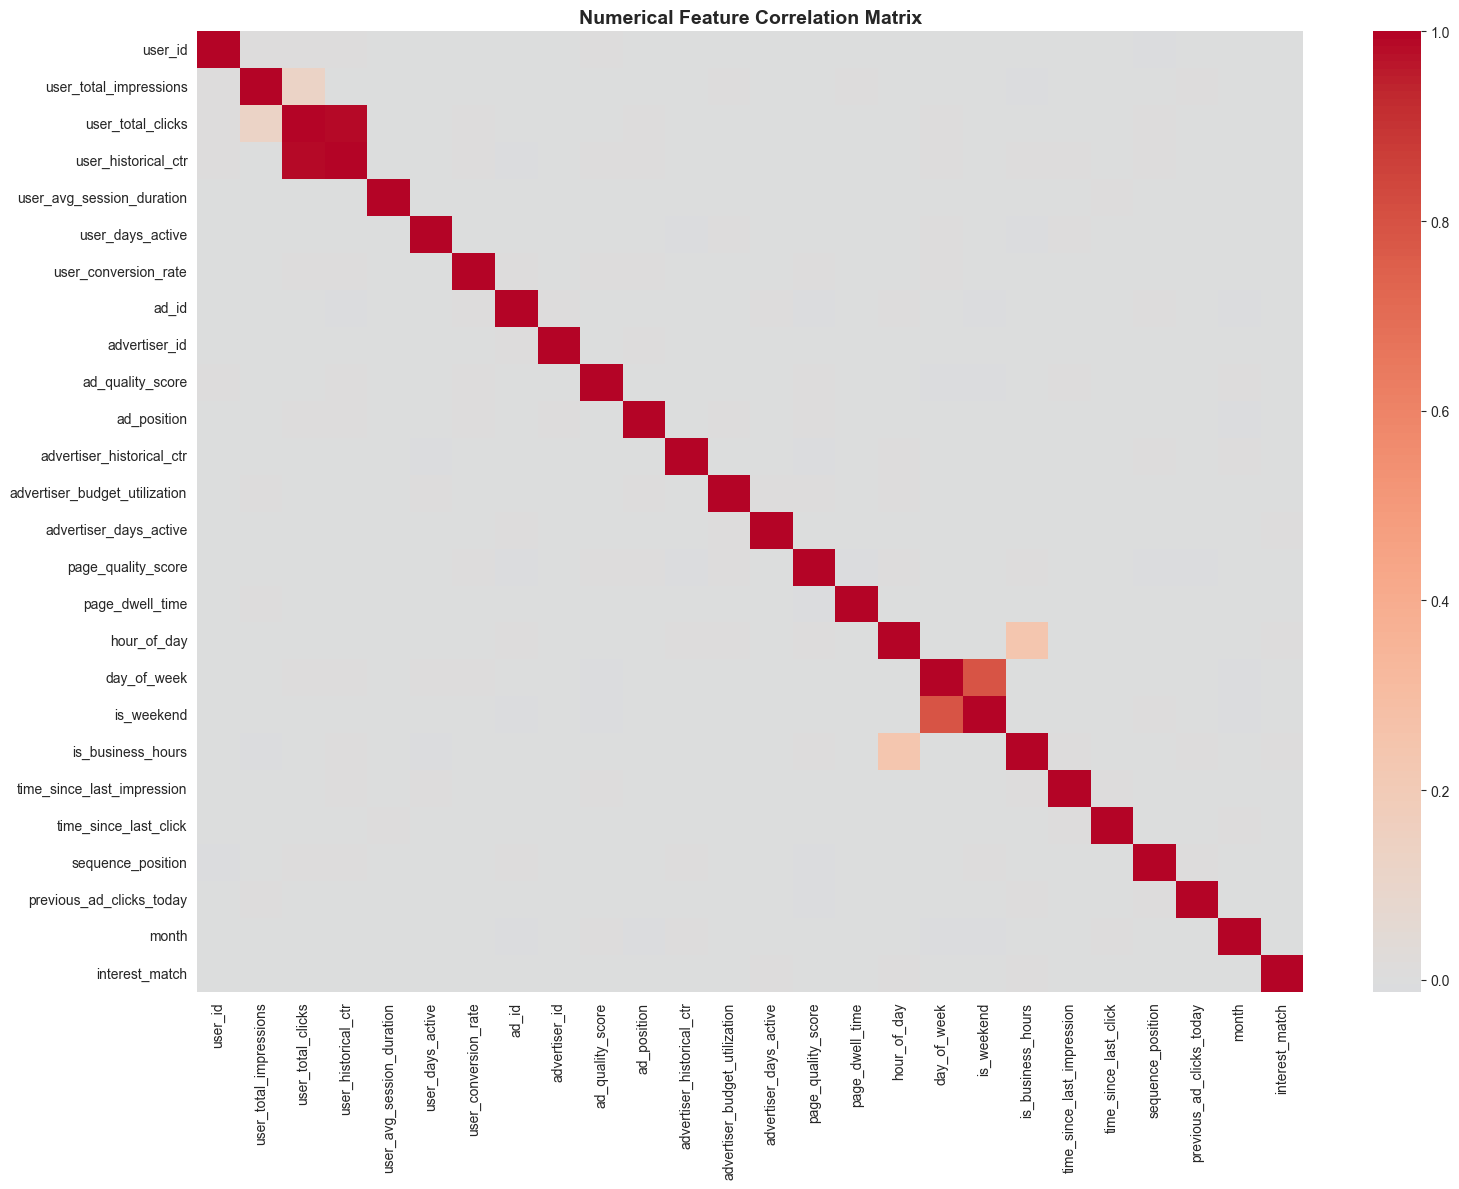


2. VARIANCE INFLATION FACTOR (VIF)
--------------------------------------------------------------------------------
                          Feature     VIF
2               user_total_clicks  137.23
3             user_historical_ctr  135.59
1          user_total_impressions   53.42
24                          month   16.36
17                    day_of_week    8.62
9                ad_quality_score    5.42
14             page_quality_score    5.38
22              sequence_position    4.68
10                    ad_position    4.64
0                         user_id    4.24
8                   advertiser_id    3.98
16                    hour_of_day    3.97
7                           ad_id    3.97
12  advertiser_budget_utilization    3.96
18                     is_weekend    3.70
6            user_conversion_rate    3.11
11      advertiser_historical_ctr    3.05
4       user_avg_session_duration    2.01
20     time_since_last_impression    2.00
15                page_dwell_time    2.00
2

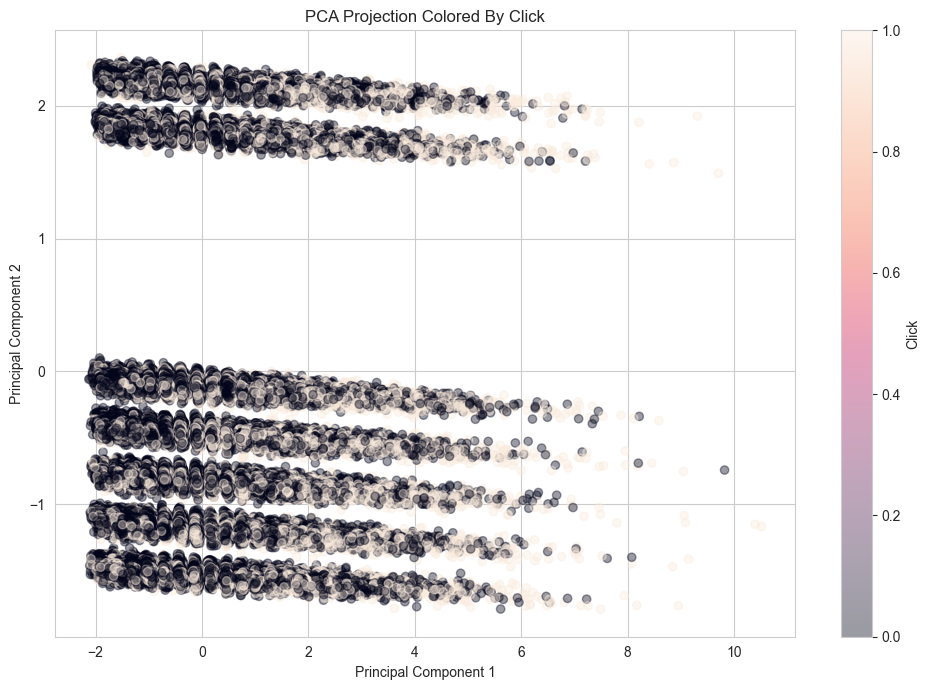


5. FEATURE INTERACTIONS
--------------------------------------------------------------------------------


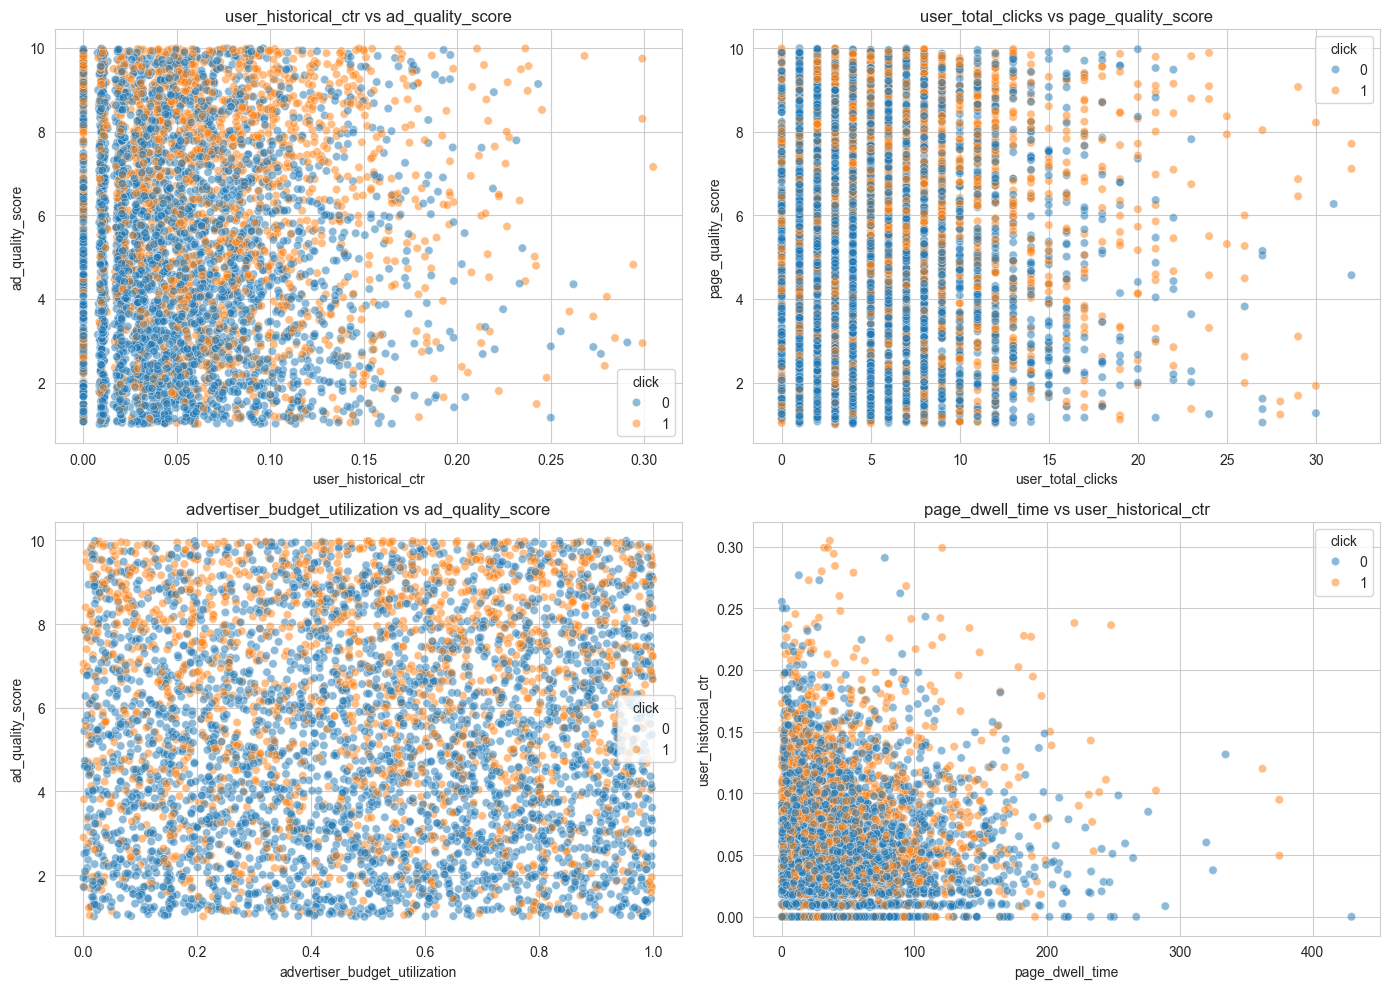


6. CTR SEGMENT ANALYSIS
--------------------------------------------------------------------------------
     Device    Ad_Category  Impressions       CTR
10   mobile         Health         7891  0.355975
7    mobile      Education         7927  0.353349
11   mobile         Retail         7853  0.349930
9    mobile        Finance         7715  0.347894
13   mobile         Travel         7895  0.346168
12   mobile     Technology         7782  0.341429
8    mobile  Entertainment         7883  0.336674
4   desktop         Retail         5037  0.320429
3   desktop         Health         4990  0.318838
6   desktop         Travel         4956  0.315981
5   desktop     Technology         5004  0.309752
2   desktop        Finance         5053  0.306748
0   desktop      Education         4977  0.304400
1   desktop  Entertainment         4923  0.300223
20   tablet         Travel         1401  0.299786

7. FEATURE CLUSTERING
-----------------------------------------------------------------------

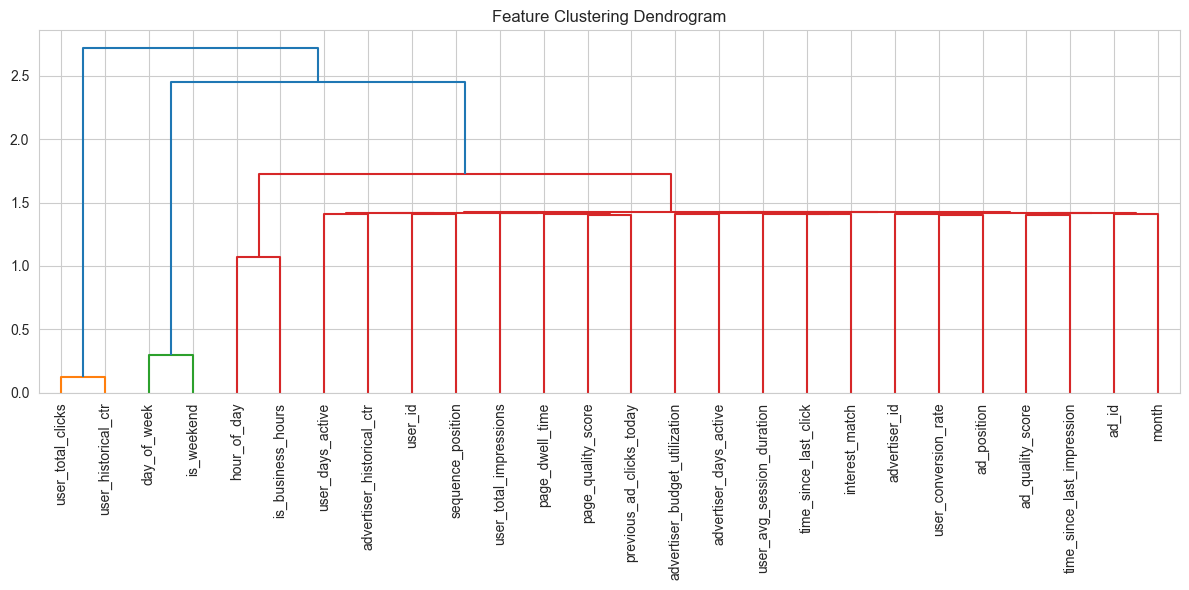


8. REDUNDANT FEATURE DETECTION
--------------------------------------------------------------------------------

Potential Features For Removal:
user_total_clicks                        VIF=137.23
user_historical_ctr                      VIF=135.59
user_total_impressions                   VIF=53.42
month                                    VIF=16.36

MULTIVARIATE ANALYSIS SUMMARY

Top Predictive Feature        : ad_quality_score
Highest MI Score              : 0.0248

Highly Correlated Pairs       : 2

High VIF Features (>10)       : 4

PCA Variance Explained        :
    PC1 = 0.0767
    PC2 = 0.0688
    Total = 0.1455

Total Numerical Features      : 26
Total Categorical Features    : 13

CTR                           : 32.89%


✓ Multivariate Analysis Completed Successfully


In [12]:
# =============================================================================
# MULTIVARIATE ANALYSIS
# =============================================================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import linkage, dendrogram

print("\n" + "=" * 100)
print("MULTIVARIATE ANALYSIS")
print("=" * 100)

# =============================================================================
# PREPARE DATA
# =============================================================================

numerical_cols = (
    df.select_dtypes(include=["int64", "float64","int32","float32"])
    .drop(columns=["click"], errors="ignore")
    .columns.tolist()
)

categorical_cols = (
    df.select_dtypes(include=["object"])
    .columns.tolist()
)

# =============================================================================
# 1. CORRELATION MATRIX
# =============================================================================

print("\n1. CORRELATION ANALYSIS")
print("-" * 80)

corr_matrix = df[numerical_cols].corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) > 0.75:

            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_val
                )
            )

if high_corr_pairs:

    print("\nHighly Correlated Features (>0.75):")

    for f1, f2, corr in sorted(
        high_corr_pairs,
        key=lambda x: abs(x[2]),
        reverse=True
    ):
        print(
            f"{f1:<40} {f2:<40} Corr={corr:.4f}"
        )
else:
    print("No strong multicollinearity detected.")

# Correlation Heatmap

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Numerical Feature Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# 2. VIF ANALYSIS
# =============================================================================

print("\n2. VARIANCE INFLATION FACTOR (VIF)")
print("-" * 80)

vif_df = pd.DataFrame()

X_vif = df[numerical_cols].fillna(0)

vif_df["Feature"] = numerical_cols

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

print(vif_df.round(2))

# =============================================================================
# 3. MUTUAL INFORMATION
# =============================================================================

print("\n3. MUTUAL INFORMATION")
print("-" * 80)

X_mi = df[numerical_cols].fillna(0)

mi_scores = mutual_info_classif(
    X_mi,
    df["click"],
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": numerical_cols,
    "MI_Score": mi_scores
})

mi_df = mi_df.sort_values(
    "MI_Score",
    ascending=False
)

print(mi_df.round(4))

# =============================================================================
# 4. PCA ANALYSIS
# =============================================================================

print("\n4. PCA ANALYSIS")
print("-" * 80)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[numerical_cols]
)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    f"PC1 Explained Variance: "
    f"{pca.explained_variance_ratio_[0]:.4f}"
)

print(
    f"PC2 Explained Variance: "
    f"{pca.explained_variance_ratio_[1]:.4f}"
)

print(
    f"Total Explained Variance: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["click"],
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Projection Colored By Click"
)

plt.colorbar(
    scatter,
    label="Click"
)

plt.tight_layout()
plt.savefig(
    "pca_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# 5. FEATURE INTERACTION ANALYSIS
# =============================================================================

print("\n5. FEATURE INTERACTIONS")
print("-" * 80)

interaction_pairs = [
    (
        "user_historical_ctr",
        "ad_quality_score"
    ),
    (
        "user_total_clicks",
        "page_quality_score"
    ),
    (
        "advertiser_budget_utilization",
        "ad_quality_score"
    ),
    (
        "page_dwell_time",
        "user_historical_ctr"
    )
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.flatten()

for idx, (f1, f2) in enumerate(interaction_pairs):

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x=f1,
        y=f2,
        hue="click",
        alpha=0.5,
        ax=axes[idx]
    )

    axes[idx].set_title(
        f"{f1} vs {f2}"
    )

plt.tight_layout()
plt.savefig(
    "feature_interactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# 6. CTR SEGMENT ANALYSIS
# =============================================================================

print("\n6. CTR SEGMENT ANALYSIS")
print("-" * 80)

segment_analysis = (
    df.groupby(
        [
            "user_device_type",
            "ad_category"
        ]
    )["click"]
    .agg(
        [
            "count",
            "mean"
        ]
    )
    .reset_index()
)

segment_analysis.columns = [
    "Device",
    "Ad_Category",
    "Impressions",
    "CTR"
]

segment_analysis = segment_analysis.sort_values(
    "CTR",
    ascending=False
)

print(
    segment_analysis.head(15)
)

# =============================================================================
# 7. FEATURE CLUSTERING
# =============================================================================

print("\n7. FEATURE CLUSTERING")
print("-" * 80)

corr_abs = np.abs(
    corr_matrix
)

linked = linkage(
    corr_abs,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    labels=corr_matrix.columns,
    leaf_rotation=90
)

plt.title(
    "Feature Clustering Dendrogram"
)

plt.tight_layout()

plt.savefig(
    "feature_clustering.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# 8. REDUNDANT FEATURES
# =============================================================================

print("\n8. REDUNDANT FEATURE DETECTION")
print("-" * 80)

redundant_features = []

for feature in vif_df["Feature"]:

    vif_value = float(
        vif_df.loc[
            vif_df["Feature"] == feature,
            "VIF"
        ].iloc[0]
    )

    if vif_value > 10:

        redundant_features.append(
            (
                feature,
                vif_value
            )
        )

if redundant_features:

    print(
        "\nPotential Features For Removal:"
    )

    for feature, vif_value in redundant_features:

        print(
            f"{feature:<40} VIF={vif_value:.2f}"
        )

else:

    print(
        "No severe multicollinearity detected."
    )

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("MULTIVARIATE ANALYSIS SUMMARY")
print("=" * 100)

top_feature = mi_df.iloc[0]["Feature"]

top_mi = mi_df.iloc[0]["MI_Score"]

high_vif_count = (
    vif_df["VIF"] > 10
).sum()

high_corr_count = len(
    high_corr_pairs
)

print(f"""
Top Predictive Feature        : {top_feature}
Highest MI Score              : {top_mi:.4f}

Highly Correlated Pairs       : {high_corr_count}

High VIF Features (>10)       : {high_vif_count}

PCA Variance Explained        :
    PC1 = {pca.explained_variance_ratio_[0]:.4f}
    PC2 = {pca.explained_variance_ratio_[1]:.4f}
    Total = {pca.explained_variance_ratio_.sum():.4f}

Total Numerical Features      : {len(numerical_cols)}
Total Categorical Features    : {len(categorical_cols)}

CTR                           : {df['click'].mean():.2%}
""")

print("\n✓ Multivariate Analysis Completed Successfully")

---

## 8. FEATURE RELATIONSHIPS & CORRELATIONS



FEATURE RELATIONSHIPS & CORRELATIONS

1. CORRELATION ANALYSIS
------------------------------------------------------------

Top 15 Features Correlated with Click:
ad_quality_score             0.209497
user_historical_ctr          0.171252
user_total_clicks            0.170163
page_quality_score           0.160503
ad_position                 -0.085092
advertiser_historical_ctr    0.081506
interest_match               0.071822
is_business_hours            0.062592
seasonality                  0.057416
month                        0.046825
timestamp                    0.044958
previous_ad_clicks_today     0.040633
hour_of_day                  0.015346
user_device_type             0.008363
user_conversion_rate         0.006014
Name: click, dtype: float64

2. VARIANCE INFLATION FACTOR (VIF)
------------------------------------------------------------
                          Feature         VIF
2               user_total_clicks  137.229526
3             user_historical_ctr  135.593993
1  

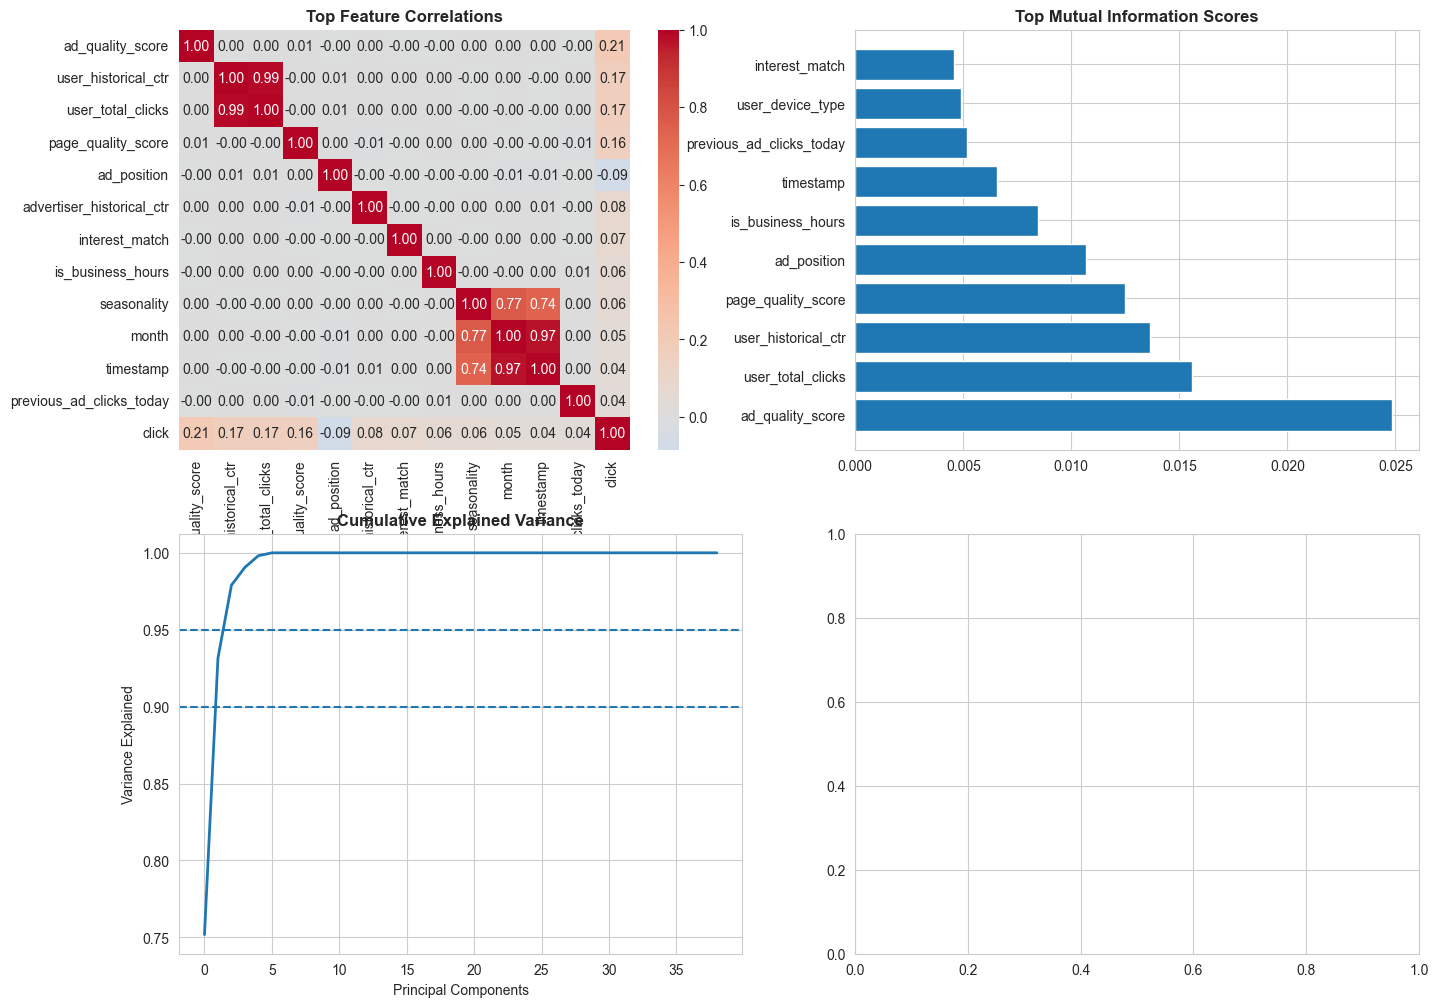


MULTIVARIATE ANALYSIS SUMMARY

Top Correlated Feature:
  ad_quality_score -> 0.2095

Most Informative Feature:
  ad_quality_score -> 0.0248

PCA Compression:
  90% variance retained using 2 components
  95% variance retained using 3 components

High Multicollinearity Features: 4
                   Feature         VIF
2        user_total_clicks  137.229526
3      user_historical_ctr  135.593993
1   user_total_impressions   53.424977
24                   month   16.363047

✓ Multivariate Analysis Completed Successfully


In [13]:
# =============================================================================
# FEATURE RELATIONSHIPS & CORRELATIONS
# =============================================================================

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost

print("\n" + "="*80)
print("FEATURE RELATIONSHIPS & CORRELATIONS")
print("="*80)

# -----------------------------------------------------------------------------
# 1. PREPARE DATA
# -----------------------------------------------------------------------------

analysis_df = df.copy()

# Encode categorical columns temporarily
encoded_df = analysis_df.copy()

for col in encoded_df.select_dtypes(include="object").columns:
    encoded_df[col] = LabelEncoder().fit_transform(
        encoded_df[col].astype(str)
    )

# -----------------------------------------------------------------------------
# 2. CORRELATION ANALYSIS
# -----------------------------------------------------------------------------

print("\n1. CORRELATION ANALYSIS")
print("-"*60)

corr_matrix = encoded_df.corr(numeric_only=True)

target_corr = (
    corr_matrix["click"]
    .drop("click")
    .sort_values(key=abs, ascending=False)
)

print("\nTop 15 Features Correlated with Click:")
print(target_corr.head(15))

# -----------------------------------------------------------------------------
# 3. MULTICOLLINEARITY (VIF)
# -----------------------------------------------------------------------------

print("\n2. VARIANCE INFLATION FACTOR (VIF)")
print("-"*60)

numeric_features = [
    col for col in numeric_cols
    if col != "click"
]

vif_df = encoded_df[numeric_features].copy()

# Remove inf values if present
vif_df = vif_df.replace([np.inf, -np.inf], np.nan)
vif_df = vif_df.fillna(vif_df.median())

vif_results = pd.DataFrame()
vif_results["Feature"] = vif_df.columns
vif_results["VIF"] = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(vif_df.shape[1])
]

vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
)

print(vif_results.head(15))

# -----------------------------------------------------------------------------
# 4. MUTUAL INFORMATION
# -----------------------------------------------------------------------------

print("\n3. MUTUAL INFORMATION SCORES")
print("-"*60)

X_mi = encoded_df.drop(columns=["click"])
y_mi = encoded_df["click"]

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_mi.columns,
    "MI Score": mi_scores
})

mi_df = mi_df.sort_values(
    "MI Score",
    ascending=False
)

print(mi_df.head(15))

# -----------------------------------------------------------------------------
# 5. PCA ANALYSIS
# -----------------------------------------------------------------------------

print("\n4. PCA VARIANCE ANALYSIS")
print("-"*60)

X_pca = encoded_df.drop(columns=["click"])

pca = PCA()
pca.fit(X_pca)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

components_90 = np.argmax(
    explained_variance >= 0.90
) + 1

components_95 = np.argmax(
    explained_variance >= 0.95
) + 1

print(f"Components for 90% variance: {components_90}")
print(f"Components for 95% variance: {components_95}")

# -----------------------------------------------------------------------------
# 6. FEATURE INTERACTIONS
# -----------------------------------------------------------------------------

print("\n5. FEATURE INTERACTION ANALYSIS")
print("-"*60)

interaction_table = (
    df.groupby(
        ["user_device_type", "ad_category"]
    )["click"]
    .mean()
    .unstack()
)

print(interaction_table)


# -----------------------------------------------------------------------------
# 8. VISUALIZATION DASHBOARD
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,12)
)

# ------------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------------

top_corr_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)

heatmap_cols = top_corr_features + ["click"]

sns.heatmap(
    encoded_df[heatmap_cols]
    .corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Top Feature Correlations",
    fontweight="bold"
)

# ------------------------------------------------------------------
# Mutual Information
# ------------------------------------------------------------------

top_mi = mi_df.head(10)

axes[0,1].barh(
    top_mi["Feature"],
    top_mi["MI Score"]
)

axes[0,1].set_title(
    "Top Mutual Information Scores",
    fontweight="bold"
)

# ------------------------------------------------------------------
# PCA Variance
# ------------------------------------------------------------------

axes[1,0].plot(
    explained_variance,
    linewidth=2
)

axes[1,0].axhline(
    0.90,
    linestyle="--"
)

axes[1,0].axhline(
    0.95,
    linestyle="--"
)

axes[1,0].set_title(
    "Cumulative Explained Variance",
    fontweight="bold"
)

axes[1,0].set_xlabel("Principal Components")
axes[1,0].set_ylabel("Variance Explained")
plt.show()

# -----------------------------------------------------------------------------
# 9. SUMMARY
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("MULTIVARIATE ANALYSIS SUMMARY")
print("="*80)

print(f"\nTop Correlated Feature:")
print(f"  {target_corr.index[0]} -> {target_corr.iloc[0]:.4f}")

print(f"\nMost Informative Feature:")
print(f"  {mi_df.iloc[0]['Feature']} -> {mi_df.iloc[0]['MI Score']:.4f}")

print(f"\nPCA Compression:")
print(f"  90% variance retained using {components_90} components")
print(f"  95% variance retained using {components_95} components")

high_vif = vif_results[vif_results["VIF"] > 10]

print(f"\nHigh Multicollinearity Features: {len(high_vif)}")

if len(high_vif) > 0:
    print(high_vif[["Feature", "VIF"]].head())

print("\n✓ Multivariate Analysis Completed Successfully")

---

## 9. CATEGORICAL FEATURES DEEP DIVE



ADVANCED CATEGORICAL FEATURE ANALYSIS

Overall Dataset CTR: 0.3289 (32.89%)

------------------------------------------------------------------------------------------
1. STATISTICAL ASSOCIATION WITH TARGET
------------------------------------------------------------------------------------------
                 Feature    Chi2       P_Value  Cramers_V Significant
10           seasonality  329.37  1.315423e-73     0.0574         Yes
3       user_device_type  201.79  1.518863e-44     0.0449         Yes
6            ad_category   14.52  2.434714e-02     0.0120         Yes
9          page_category    9.47  1.489653e-01     0.0097          No
0         user_age_group    4.43  3.509066e-01     0.0067          No
5           user_browser    2.60  4.574106e-01     0.0051          No
8                ad_size    2.04  5.646415e-01     0.0045          No
4                user_os    1.72  6.331935e-01     0.0041          No
1            user_gender    1.12  5.709467e-01     0.0033          No
2

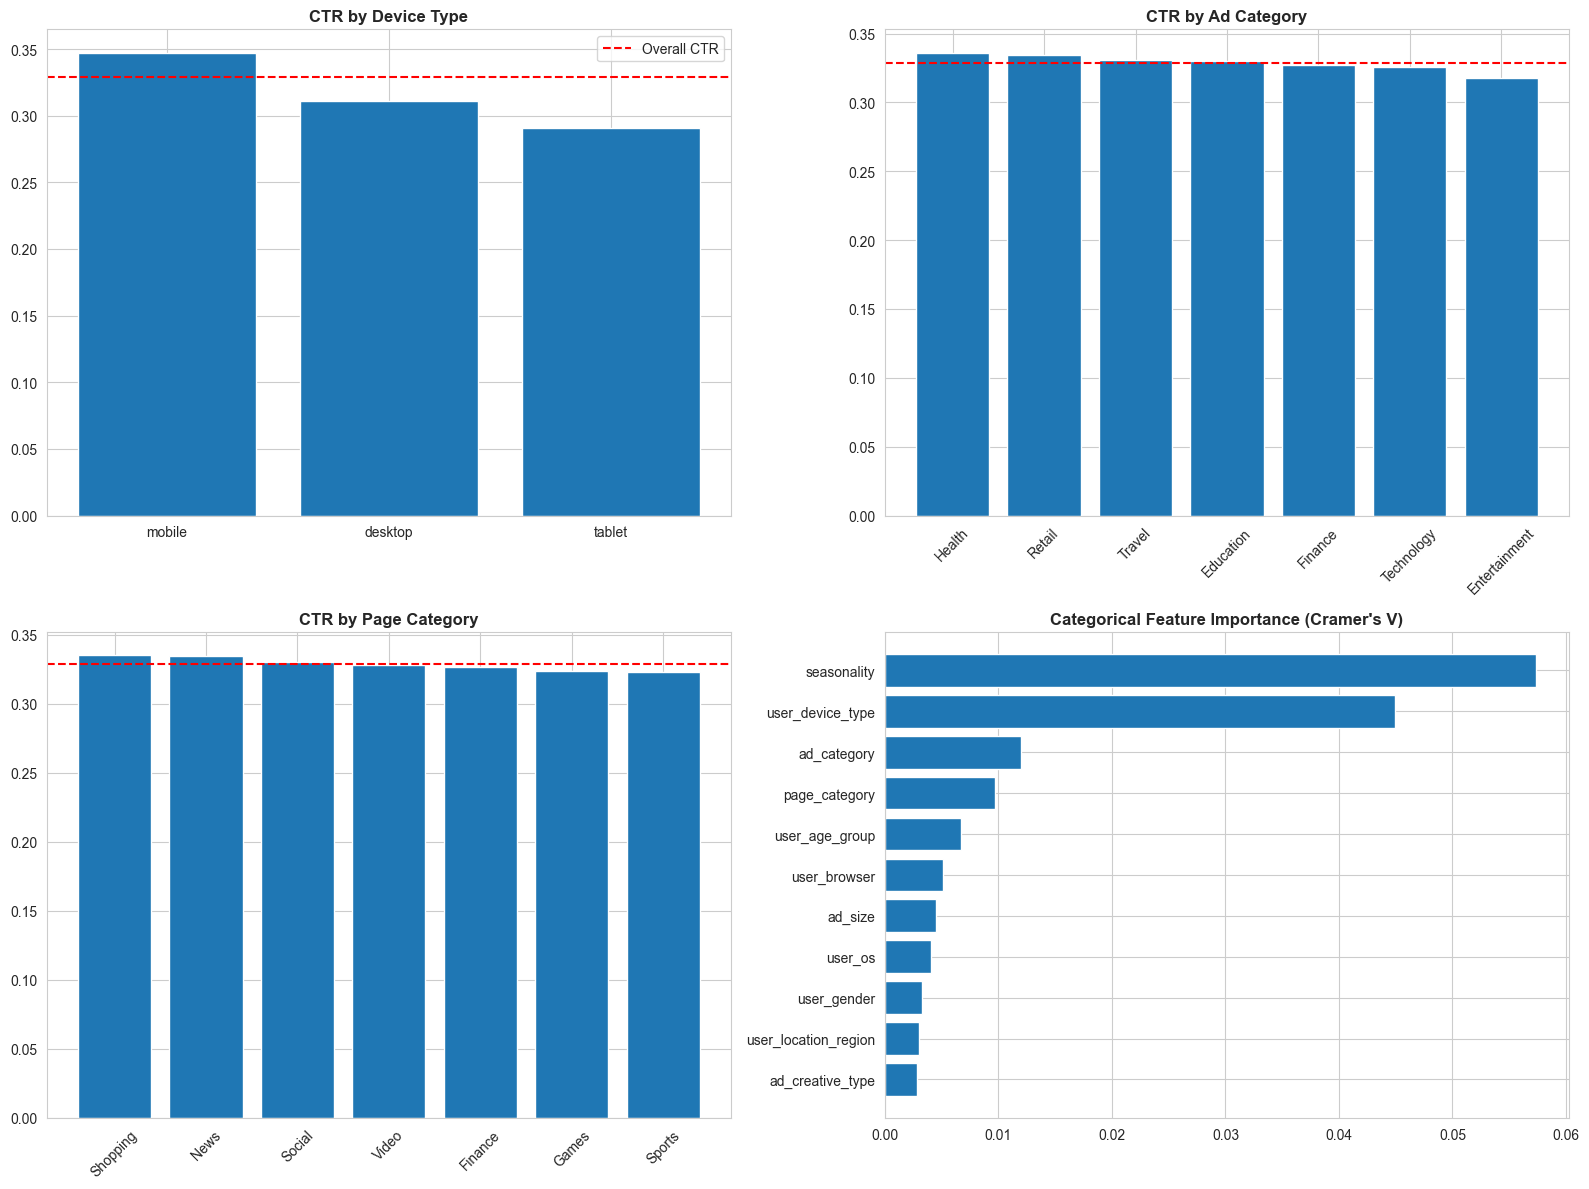


✓ Advanced categorical analysis completed


In [14]:
# =============================================================================
# ADVANCED CATEGORICAL FEATURE ANALYSIS
# =============================================================================

from scipy.stats import chi2_contingency

print("\n" + "=" * 90)
print("ADVANCED CATEGORICAL FEATURE ANALYSIS")
print("=" * 90)

categorical_features = [
    "user_age_group",
    "user_gender",
    "user_location_region",
    "user_device_type",
    "user_os",
    "user_browser",
    "ad_category",
    "ad_creative_type",
    "ad_size",
    "page_category",
    "seasonality"
]

overall_ctr = df["click"].mean()

print(f"\nOverall Dataset CTR: {overall_ctr:.4f} ({overall_ctr*100:.2f}%)")

# =============================================================================
# 1. CHI-SQUARE + CRAMER'S V
# =============================================================================

print("\n" + "-" * 90)
print("1. STATISTICAL ASSOCIATION WITH TARGET")
print("-" * 90)

association_results = []

for col in categorical_features:

    if col not in df.columns:
        continue

    contingency = pd.crosstab(df[col], df["click"])

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()

    cramers_v = np.sqrt(
        chi2 /
        (n * (min(contingency.shape)-1))
    )

    association_results.append({
        "Feature": col,
        "Chi2": round(chi2, 2),
        "P_Value": p_value,
        "Cramers_V": round(cramers_v, 4),
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

association_df = pd.DataFrame(association_results)
association_df = association_df.sort_values(
    "Cramers_V",
    ascending=False
)

print(association_df)

# =============================================================================
# 2. CARDINALITY ANALYSIS
# =============================================================================

print("\n" + "-" * 90)
print("2. CARDINALITY ANALYSIS")
print("-" * 90)

cardinality_results = []

for col in categorical_features:

    if col not in df.columns:
        continue

    unique_values = df[col].nunique()

    cardinality_results.append({
        "Feature": col,
        "Unique Categories": unique_values,
        "Cardinality":
            "Low" if unique_values <= 10
            else "Medium" if unique_values <= 50
            else "High"
    })

cardinality_df = pd.DataFrame(cardinality_results)
print(cardinality_df)

# =============================================================================
# 3. CTR LIFT ANALYSIS
# =============================================================================

print("\n" + "-" * 90)
print("3. CTR LIFT ANALYSIS")
print("-" * 90)

for feature in [
    "user_device_type",
    "user_age_group",
    "ad_category",
    "page_category"
]:

    if feature not in df.columns:
        continue

    temp = (
        df.groupby(feature)
        .agg(
            impressions=("click", "count"),
            clicks=("click", "sum"),
            ctr=("click", "mean")
        )
        .reset_index()
    )

    temp["ctr_lift"] = (
        temp["ctr"] / overall_ctr
    )

    temp = temp.sort_values(
        "ctr",
        ascending=False
    )

    print(f"\n{feature.upper()}")
    print(temp)

# =============================================================================
# 4. CATEGORY CONTRIBUTION TO TOTAL CLICKS
# =============================================================================

print("\n" + "-" * 90)
print("4. CATEGORY CONTRIBUTION TO TOTAL CLICKS")
print("-" * 90)

for feature in ["ad_category", "page_category"]:

    if feature not in df.columns:
        continue

    contribution = (
        df.groupby(feature)
        .agg(
            total_clicks=("click", "sum")
        )
        .sort_values(
            "total_clicks",
            ascending=False
        )
    )

    contribution["click_share_%"] = (
        contribution["total_clicks"]
        / contribution["total_clicks"].sum()
        * 100
    )

    print(f"\n{feature.upper()}")
    print(contribution)

# =============================================================================
# 5. RARE CATEGORY DETECTION
# =============================================================================

print("\n" + "-" * 90)
print("5. RARE CATEGORY DETECTION")
print("-" * 90)

for col in categorical_features:

    if col not in df.columns:
        continue

    freq = (
        df[col]
        .value_counts(normalize=True)
        * 100
    )

    rare = freq[freq < 1]

    if len(rare) > 0:

        print(f"\n{col}")
        print("Rare Categories (<1% frequency):")

        print(
            rare.sort_values(
                ascending=True
            )
        )

# =============================================================================
# 6. VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

# ----------------------------------------------------
# Device CTR
# ----------------------------------------------------
device_ctr = (
    df.groupby("user_device_type")["click"]
    .mean()
    .sort_values(ascending=False)
)

axes[0,0].bar(
    device_ctr.index,
    device_ctr.values
)

axes[0,0].axhline(
    overall_ctr,
    color="red",
    linestyle="--",
    label="Overall CTR"
)

axes[0,0].set_title(
    "CTR by Device Type",
    fontweight="bold"
)

axes[0,0].legend()

# ----------------------------------------------------
# Ad Category CTR
# ----------------------------------------------------
ad_ctr = (
    df.groupby("ad_category")["click"]
    .mean()
    .sort_values(ascending=False)
)

axes[0,1].bar(
    ad_ctr.index,
    ad_ctr.values
)

axes[0,1].axhline(
    overall_ctr,
    color="red",
    linestyle="--"
)

axes[0,1].set_title(
    "CTR by Ad Category",
    fontweight="bold"
)

axes[0,1].tick_params(
    axis="x",
    rotation=45
)

# ----------------------------------------------------
# Page Category CTR
# ----------------------------------------------------
page_ctr = (
    df.groupby("page_category")["click"]
    .mean()
    .sort_values(ascending=False)
)

axes[1,0].bar(
    page_ctr.index,
    page_ctr.values
)

axes[1,0].axhline(
    overall_ctr,
    color="red",
    linestyle="--"
)

axes[1,0].set_title(
    "CTR by Page Category",
    fontweight="bold"
)

axes[1,0].tick_params(
    axis="x",
    rotation=45
)

# ----------------------------------------------------
# Cramer's V
# ----------------------------------------------------
association_df_sorted = association_df.sort_values(
    "Cramers_V",
    ascending=True
)

axes[1,1].barh(
    association_df_sorted["Feature"],
    association_df_sorted["Cramers_V"]
)

axes[1,1].set_title(
    "Categorical Feature Importance (Cramer's V)",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "advanced_categorical_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Advanced categorical analysis completed")

---

## 10. TEMPORAL ANALYSIS



ADVANCED TEMPORAL ANALYSIS

Overall CTR: 0.3289 (32.89%)

------------------------------------------------------------------------------------------
1. HOUR OF DAY ANALYSIS
------------------------------------------------------------------------------------------
             impressions  clicks       ctr  ctr_lift
hour_of_day                                         
0                   4168    1228  0.294626  0.895709
1                   4167    1217  0.292057  0.887899
2                   4166    1308  0.313970  0.954520
3                   4167    1293  0.310295  0.943347
4                   4167    1292  0.310055  0.942618
5                   4166    1254  0.301008  0.915113
6                   4167    1282  0.307655  0.935322
7                   4166    1293  0.310370  0.943574
8                   4167    1225  0.293976  0.893736
9                   4167    1561  0.374610  1.138875
10                  4166    1475  0.354057  1.076389
11                  4167    1541  0.369810  1.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


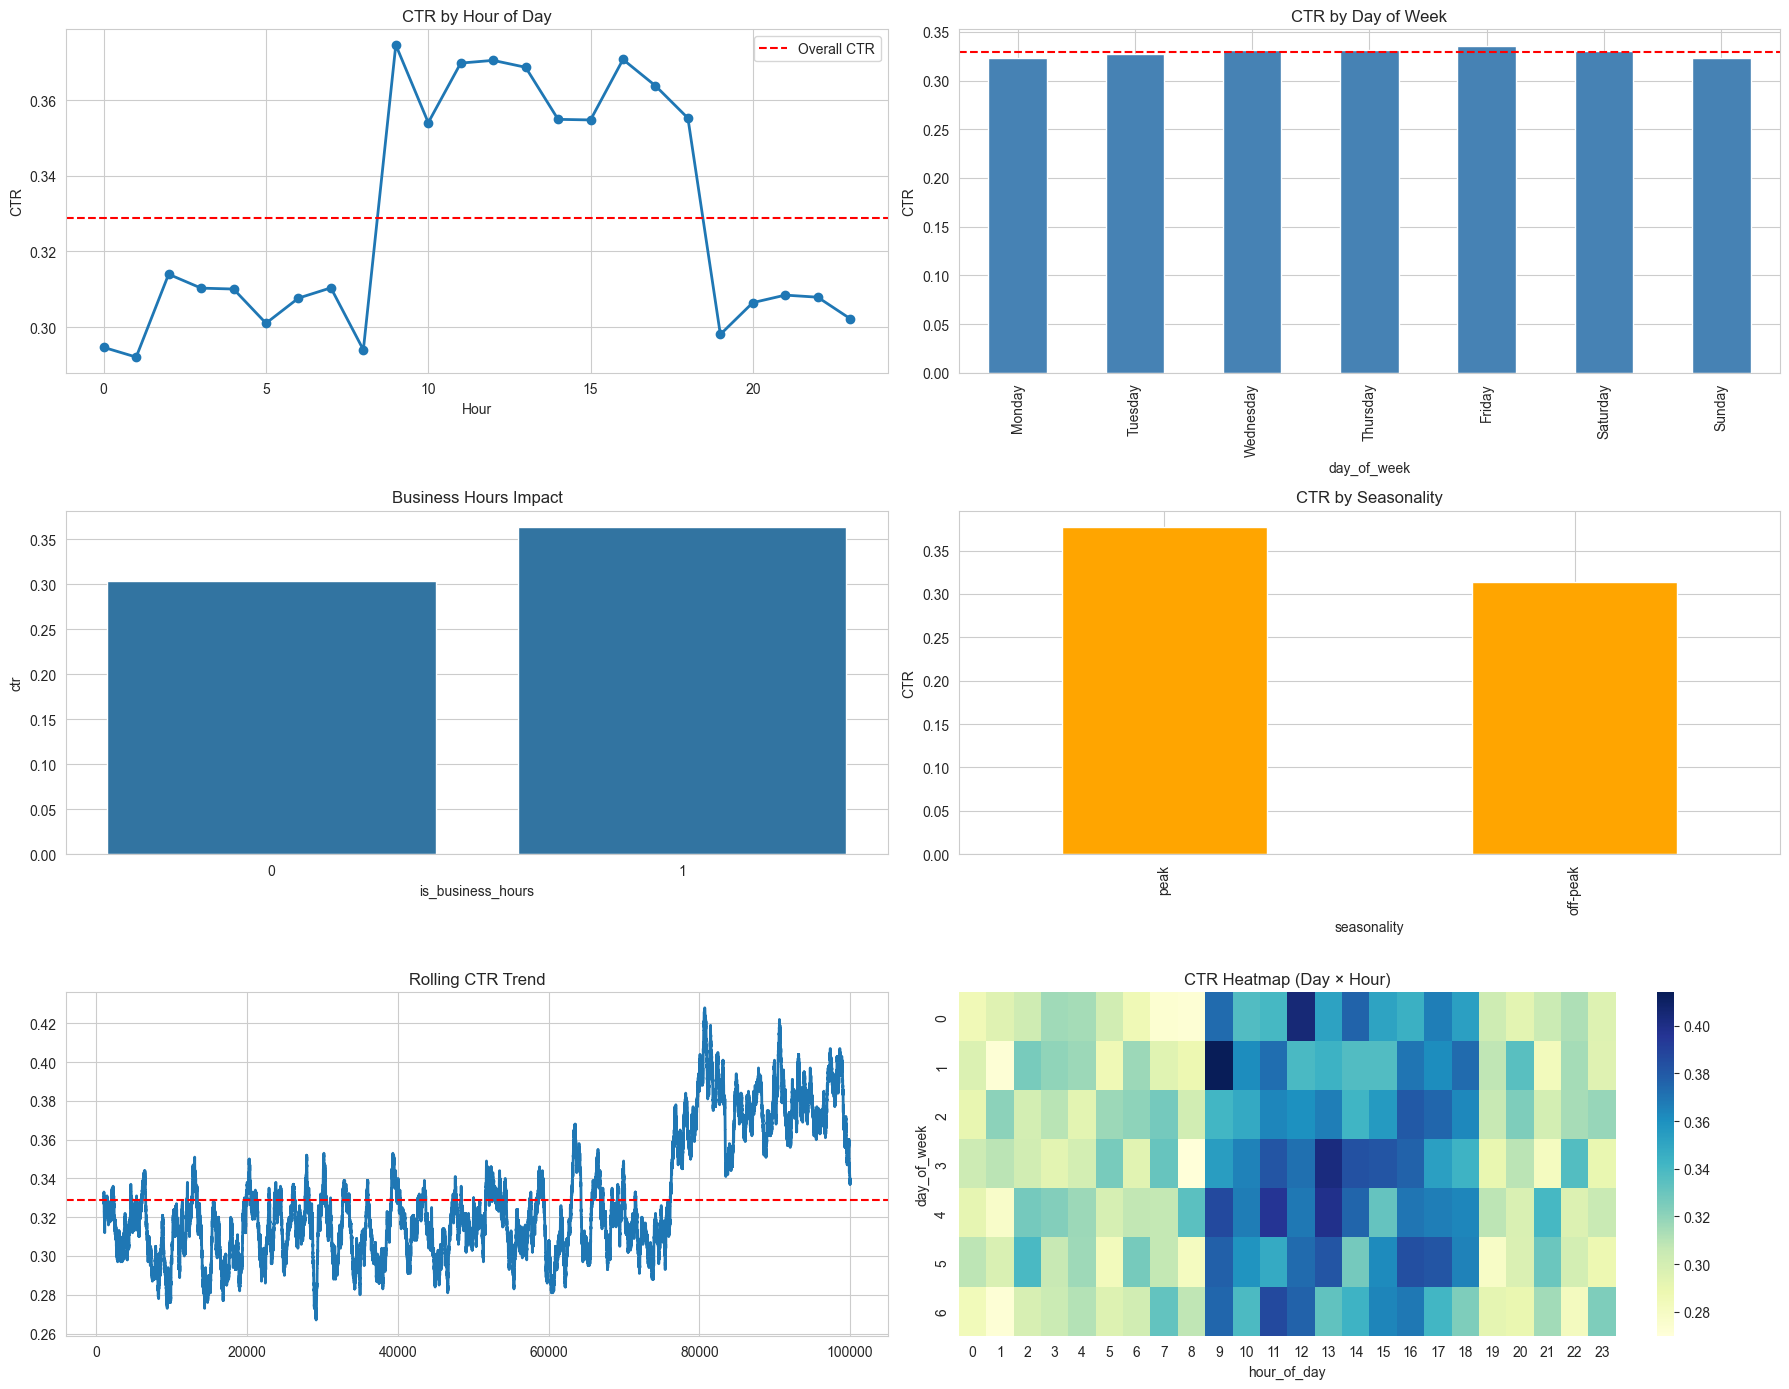


TEMPORAL ANALYSIS SUMMARY

Overall CTR              : 0.3289

Best Hour               : 9
Worst Hour              : 1

Weekend CTR Difference  : -0.30%

CTR Drift (%)           : 20.72%

Highest Season CTR      : peak
Lowest Season CTR       : off-peak


✓ Advanced Temporal Analysis Completed


In [15]:
# =============================================================================
# ADVANCED TEMPORAL ANALYSIS
# =============================================================================
from scipy.stats import ttest_ind

print("\n" + "="*90)
print("ADVANCED TEMPORAL ANALYSIS")
print("="*90)

# -----------------------------------------------------------------------------
# PREPARATION
# -----------------------------------------------------------------------------

df["timestamp"] = pd.to_datetime(df["timestamp"])

overall_ctr = df["click"].mean()

print(f"\nOverall CTR: {overall_ctr:.4f} ({overall_ctr*100:.2f}%)")

# =============================================================================
# 1. HOUR OF DAY ANALYSIS
# =============================================================================

print("\n" + "-"*90)
print("1. HOUR OF DAY ANALYSIS")
print("-"*90)

hourly_stats = (
    df.groupby("hour_of_day")
      .agg(
          impressions=("click","count"),
          clicks=("click","sum"),
          ctr=("click","mean")
      )
)

hourly_stats["ctr_lift"] = hourly_stats["ctr"] / overall_ctr

print(hourly_stats)

best_hour = hourly_stats["ctr"].idxmax()
worst_hour = hourly_stats["ctr"].idxmin()

print(f"\nBest Hour : {best_hour}")
print(f"Worst Hour: {worst_hour}")

# =============================================================================
# 2. DAY OF WEEK ANALYSIS
# =============================================================================

print("\n" + "-"*90)
print("2. DAY OF WEEK ANALYSIS")
print("-"*90)

day_mapping = {
    0:"Monday",
    1:"Tuesday",
    2:"Wednesday",
    3:"Thursday",
    4:"Friday",
    5:"Saturday",
    6:"Sunday"
}

dow_stats = (
    df.groupby("day_of_week")
      .agg(
          impressions=("click","count"),
          clicks=("click","sum"),
          ctr=("click","mean")
      )
)

dow_stats.index = dow_stats.index.map(day_mapping)

print(dow_stats)

# =============================================================================
# 3. WEEKDAY VS WEEKEND
# =============================================================================

print("\n" + "-"*90)
print("3. WEEKDAY VS WEEKEND")
print("-"*90)

weekend_stats = (
    df.groupby("is_weekend")
      .agg(
          impressions=("click","count"),
          clicks=("click","sum"),
          ctr=("click","mean")
      )
)

print(weekend_stats)

weekday_ctr = df[df["is_weekend"] == 0]["click"]
weekend_ctr = df[df["is_weekend"] == 1]["click"]

t_stat, p_value = ttest_ind(
    weekday_ctr,
    weekend_ctr,
    equal_var=False
)

print(f"\nT-Test p-value: {p_value:.6f}")

if p_value < 0.05:
    print("✓ Significant difference between weekday and weekend CTR")
else:
    print("✗ No significant difference")

# =============================================================================
# 4. BUSINESS HOURS ANALYSIS
# =============================================================================

print("\n" + "-"*90)
print("4. BUSINESS HOURS ANALYSIS")
print("-"*90)

business_stats = (
    df.groupby("is_business_hours")
      .agg(
          impressions=("click","count"),
          clicks=("click","sum"),
          ctr=("click","mean")
      )
)

print(business_stats)

# =============================================================================
# 5. MONTHLY ANALYSIS
# =============================================================================

print("\n" + "-"*90)
print("5. MONTHLY ANALYSIS")
print("-"*90)

monthly_stats = (
    df.groupby("month")
      .agg(
          impressions=("click","count"),
          clicks=("click","sum"),
          ctr=("click","mean")
      )
)

print(monthly_stats)

# =============================================================================
# 6. SEASONALITY ANALYSIS
# =============================================================================

print("\n" + "-"*90)
print("6. SEASONALITY ANALYSIS")
print("-"*90)

season_stats = (
    df.groupby("seasonality")
      .agg(
          impressions=("click","count"),
          clicks=("click","sum"),
          ctr=("click","mean")
      )
      .sort_values("ctr", ascending=False)
)

print(season_stats)

# =============================================================================
# 7. TEMPORAL DRIFT ANALYSIS
# =============================================================================

print("\n" + "-"*90)
print("7. TEMPORAL DRIFT ANALYSIS")
print("-"*90)

df_sorted = df.sort_values("timestamp").copy()

first_period_ctr = df_sorted.iloc[:len(df)//4]["click"].mean()
last_period_ctr = df_sorted.iloc[-len(df)//4:]["click"].mean()

ctr_change = (
    (last_period_ctr - first_period_ctr)
    / first_period_ctr
) * 100

print(f"Initial Period CTR : {first_period_ctr:.4f}")
print(f"Final Period CTR   : {last_period_ctr:.4f}")
print(f"CTR Change (%)     : {ctr_change:.2f}%")

# =============================================================================
# 8. HOUR × DAY HEATMAP
# =============================================================================

hour_day_ctr = pd.pivot_table(
    df,
    values="click",
    index="day_of_week",
    columns="hour_of_day",
    aggfunc="mean"
)

# =============================================================================
# 9. VISUALIZATIONS
# =============================================================================

fig = plt.figure(figsize=(18,14))

# -------------------------------------------------
# Hourly CTR
# -------------------------------------------------

plt.subplot(3,2,1)

plt.plot(
    hourly_stats.index,
    hourly_stats["ctr"],
    marker="o",
    linewidth=2
)

plt.axhline(
    overall_ctr,
    linestyle="--",
    color="red",
    label="Overall CTR"
)

plt.title("CTR by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("CTR")
plt.legend()
plt.grid(True)

# -------------------------------------------------
# Day of Week
# -------------------------------------------------

plt.subplot(3,2,2)

dow_stats["ctr"].plot(
    kind="bar",
    color="steelblue"
)

plt.axhline(
    overall_ctr,
    color="red",
    linestyle="--"
)

plt.title("CTR by Day of Week")
plt.ylabel("CTR")

# -------------------------------------------------
# Weekend vs Weekday
# -------------------------------------------------

plt.subplot(3,2,3)

sns.barplot(
    x=business_stats.index,
    y=business_stats["ctr"]
)

plt.title("Business Hours Impact")

# -------------------------------------------------
# Seasonality
# -------------------------------------------------

plt.subplot(3,2,4)

season_stats["ctr"].plot(
    kind="bar",
    color="orange"
)

plt.title("CTR by Seasonality")
plt.ylabel("CTR")

# -------------------------------------------------
# Rolling CTR
# -------------------------------------------------

plt.subplot(3,2,5)

df_sorted["rolling_ctr"] = (
    df_sorted["click"]
    .rolling(1000)
    .mean()
)

plt.plot(
    df_sorted["rolling_ctr"],
    linewidth=2
)

plt.axhline(
    overall_ctr,
    color="red",
    linestyle="--"
)

plt.title("Rolling CTR Trend")

# -------------------------------------------------
# Heatmap
# -------------------------------------------------

plt.subplot(3,2,6)

sns.heatmap(
    hour_day_ctr,
    cmap="YlGnBu"
)

plt.title("CTR Heatmap (Day × Hour)")

plt.tight_layout()

plt.savefig(
    "advanced_temporal_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "="*90)
print("TEMPORAL ANALYSIS SUMMARY")
print("="*90)

print(f"""
Overall CTR              : {overall_ctr:.4f}

Best Hour               : {best_hour}
Worst Hour              : {worst_hour}

Weekend CTR Difference  : {(weekend_ctr.mean()-weekday_ctr.mean())*100:.2f}%

CTR Drift (%)           : {ctr_change:.2f}%

Highest Season CTR      : {season_stats.index[0]}
Lowest Season CTR       : {season_stats.index[-1]}
""")

print("\n✓ Advanced Temporal Analysis Completed")

---

## 11. STATISTICAL INSIGHTS & TESTS


In [16]:
# =============================================================================
# ADVANCED STATISTICAL TESTS & INSIGHTS REPORT
# =============================================================================

from scipy.stats import (
    pointbiserialr,
    ttest_ind,
    mannwhitneyu,
    f_oneway,
    chi2_contingency,
    ks_2samp
)

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("\n" + "="*100)
print(" " * 25 + "ADVANCED STATISTICAL TESTS & INSIGHTS")
print("="*100)

# =============================================================================
# DEFINE FEATURES
# =============================================================================

target = "click"

numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_cols = [c for c in numerical_cols if c != target]

categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()

if "timestamp" in categorical_cols:
    categorical_cols.remove("timestamp")

# =============================================================================
# 1. POINT BISERIAL CORRELATION
# =============================================================================

print("\n1. POINT-BISERIAL CORRELATION")
print("-"*100)

pb_results = []

for col in numerical_cols:

    try:
        corr, p = pointbiserialr(df[target], df[col])

        pb_results.append({
            "Feature": col,
            "Correlation": corr,
            "P_Value": p
        })

    except:
        pass

pb_df = pd.DataFrame(pb_results)

pb_df = pb_df.sort_values(
    "Correlation",
    key=np.abs,
    ascending=False
)

print(pb_df.head(20).to_string(index=False))

# =============================================================================
# 2. T-TEST + COHEN D
# =============================================================================

print("\n2. T-TEST + EFFECT SIZE")
print("-"*100)

def cohens_d(group1, group2):

    pooled_std = np.sqrt(
        ((group1.var() + group2.var()) / 2)
    )

    return (
        (group1.mean() - group2.mean())
        / pooled_std
    )

ttest_results = []

for col in numerical_cols:

    click = df[df[target]==1][col]
    no_click = df[df[target]==0][col]

    try:

        t_stat,p = ttest_ind(
            click,
            no_click,
            equal_var=False
        )

        d = cohens_d(click,no_click)

        ttest_results.append({
            "Feature":col,
            "T_Statistic":t_stat,
            "P_Value":p,
            "Cohen_D":d
        })

    except:
        pass

ttest_df = pd.DataFrame(ttest_results)

ttest_df = ttest_df.sort_values(
    "Cohen_D",
    key=np.abs,
    ascending=False
)

print(ttest_df.head(20).to_string(index=False))

# =============================================================================
# 3. MANN WHITNEY U TEST
# =============================================================================

print("\n3. MANN-WHITNEY U TEST")
print("-"*100)

mw_results = []

for col in numerical_cols:

    try:

        stat,p = mannwhitneyu(
            df[df[target]==1][col],
            df[df[target]==0][col]
        )

        mw_results.append({
            "Feature":col,
            "P_Value":p
        })

    except:
        pass

mw_df = pd.DataFrame(mw_results)

print(
    mw_df.sort_values("P_Value")
    .head(15)
    .to_string(index=False)
)

# =============================================================================
# 4. KS TEST
# =============================================================================

print("\n4. KOLMOGOROV-SMIRNOV TEST")
print("-"*100)

ks_results = []

for col in numerical_cols:

    try:

        ks_stat,p = ks_2samp(
            df[df[target]==1][col],
            df[df[target]==0][col]
        )

        ks_results.append({
            "Feature":col,
            "KS_Statistic":ks_stat,
            "P_Value":p
        })

    except:
        pass

ks_df = pd.DataFrame(
    ks_results
).sort_values(
    "KS_Statistic",
    ascending=False
)

print(ks_df.head(20).to_string(index=False))

# =============================================================================
# 5. ANOVA TEST
# =============================================================================

print("\n5. ANOVA TEST")
print("-"*100)

anova_results = []

for col in categorical_cols:

    try:

        groups = []

        for cat in df[col].dropna().unique():

            groups.append(
                df[df[col]==cat][target]
            )

        f_stat,p = f_oneway(*groups)

        anova_results.append({
            "Feature":col,
            "F_Score":f_stat,
            "P_Value":p
        })

    except:
        pass

anova_df = pd.DataFrame(
    anova_results
).sort_values(
    "F_Score",
    ascending=False
)

print(anova_df.to_string(index=False))

# =============================================================================
# 6. CHI-SQUARE + CRAMERS V
# =============================================================================

print("\n6. CHI-SQUARE + CRAMER'S V")
print("-"*100)

chi_results = []

for col in categorical_cols:

    try:

        contingency = pd.crosstab(
            df[col],
            df[target]
        )

        chi2,p,dof,expected = chi2_contingency(
            contingency
        )

        n = contingency.sum().sum()

        cramers_v = np.sqrt(
            chi2/(n*(min(contingency.shape)-1))
        )

        chi_results.append({
            "Feature":col,
            "Chi2":chi2,
            "P_Value":p,
            "Cramers_V":cramers_v
        })

    except:
        pass

chi_df = pd.DataFrame(
    chi_results
).sort_values(
    "Cramers_V",
    ascending=False
)

print(chi_df.to_string(index=False))

# =============================================================================
# 7. MUTUAL INFORMATION
# =============================================================================

print("\n7. MUTUAL INFORMATION")
print("-" * 100)

temp = df.copy()

target = "click"

# Encode categorical columns
categorical_cols = temp.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    temp[col] = LabelEncoder().fit_transform(
        temp[col].astype(str)
    )

# Convert datetime columns if present
if "timestamp" in temp.columns:
    temp["timestamp"] = pd.to_datetime(temp["timestamp"])
    temp["timestamp"] = temp["timestamp"].astype("int64") // 10**9

# Features and target
X = temp.drop(columns=[target], errors="ignore")
y = temp[target]

# Mutual Information
mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

print(mi_df.head(20).to_string(index=False))

# =============================================================================
# 7. VIF ANALYSIS
# =============================================================================

print("\n7. MULTICOLLINEARITY CHECK (VIF)")
print("-"*100)

try:

    X_num = df[numerical_cols].fillna(0)

    X_num = add_constant(X_num)

    vif_df = pd.DataFrame()

    vif_df["Feature"] = X_num.columns

    vif_df["VIF"] = [
        variance_inflation_factor(
            X_num.values,
            i
        )
        for i in range(X_num.shape[1])
    ]

    vif_df = vif_df.sort_values(
        "VIF",
        ascending=False
    )

    print(vif_df.to_string(index=False))

except Exception as e:

    print(f"VIF Failed: {e}")

# =============================================================================
# 8. OVERALL FEATURE STRENGTH SCORE
# =============================================================================

print("\n8. FEATURE STRENGTH RANKING")
print("-"*100)

feature_strength = pd.DataFrame({
    "Feature": mi_df["Feature"],
    "Mutual_Info": mi_df["Mutual_Information"]
})

if not pb_df.empty:

    feature_strength = feature_strength.merge(
        pb_df[["Feature","Correlation"]],
        how="left"
    )

feature_strength["Correlation"] = (
    feature_strength["Correlation"]
    .abs()
    .fillna(0)
)

feature_strength["Overall_Score"] = (
    feature_strength["Mutual_Info"]*0.7 +
    feature_strength["Correlation"]*0.3
)

feature_strength = feature_strength.sort_values(
    "Overall_Score",
    ascending=False
)

print(feature_strength.head(20).to_string(index=False))

# =============================================================================
# 9. EXECUTIVE INSIGHTS
# =============================================================================

print("\n9. EXECUTIVE STATISTICAL INSIGHTS")
print("-"*100)

print(f"\nTop Predictive Features:")
for feat in feature_strength.head(10)["Feature"]:
    print(f"  ✓ {feat}")

print("\nStrong Numerical Drivers:")
for feat in pb_df.head(5)["Feature"]:
    print(f"  ✓ {feat}")

print("\nStrong Categorical Drivers:")
for feat in chi_df.head(5)["Feature"]:
    print(f"  ✓ {feat}")

print("\nPotential Multicollinearity:")
try:
    high_vif = vif_df[vif_df["VIF"] > 10]["Feature"].tolist()

    if high_vif:
        for feat in high_vif:
            print(f"  ⚠ {feat}")
    else:
        print("  ✓ None detected")
except:
    pass

print("\nRecommended Modeling Strategy:")
print("""
✓ Tree-Based Models:
   - XGBoost
   - LightGBM
   - CatBoost

✓ Handle Class Imbalance:
   - scale_pos_weight
   - SMOTE (train only)

✓ Evaluation Metrics:
   - ROC-AUC
   - PR-AUC
   - Log Loss
   - F1 Score

✓ Feature Selection:
   - Mutual Information
   - SHAP Importance
   - Recursive Feature Elimination

✓ Validation:
   - Time-Based Split
   - Stratified Split
""")

print("\n" + "="*100)
print("ADVANCED STATISTICAL ANALYSIS COMPLETED")
print("="*100)


                         ADVANCED STATISTICAL TESTS & INSIGHTS

1. POINT-BISERIAL CORRELATION
----------------------------------------------------------------------------------------------------
                      Feature  Correlation       P_Value
             ad_quality_score     0.209497  0.000000e+00
          user_historical_ctr     0.171252  0.000000e+00
            user_total_clicks     0.170163  0.000000e+00
           page_quality_score     0.160503  0.000000e+00
                  ad_position    -0.085092 4.715004e-160
    advertiser_historical_ctr     0.081506 5.717292e-147
               interest_match     0.071822 1.750705e-114
            is_business_hours     0.062592  2.316717e-87
                        month     0.046825  1.165686e-49
     previous_ad_clicks_today     0.040633  8.106108e-38
                  hour_of_day     0.015346  1.216636e-06
         user_conversion_rate     0.006014  5.720254e-02
       user_total_impressions     0.005849  6.436402e-02
advert

---

## 12. OUTLIER DETECTION & ANOMALIES



OUTLIER DETECTION & ANOMALY ANALYSIS

1. IQR OUTLIER ANALYSIS
------------------------------------------------------------
                      Feature  Outliers  Percentage
               interest_match     14190       14.19
       advertiser_days_active      5000        5.00
             user_days_active      4881        4.88
        time_since_last_click      4834        4.83
    user_avg_session_duration      4790        4.79
   time_since_last_impression      4786        4.79
              page_dwell_time      4686        4.69
         user_conversion_rate      2874        2.87
    advertiser_historical_ctr      2746        2.75
          user_historical_ctr      2653        2.65
            user_total_clicks      2587        2.59
       user_total_impressions       436        0.44
     previous_ad_clicks_today        64        0.06
                   is_weekend         0        0.00
                        month         0        0.00
            sequence_position         0     

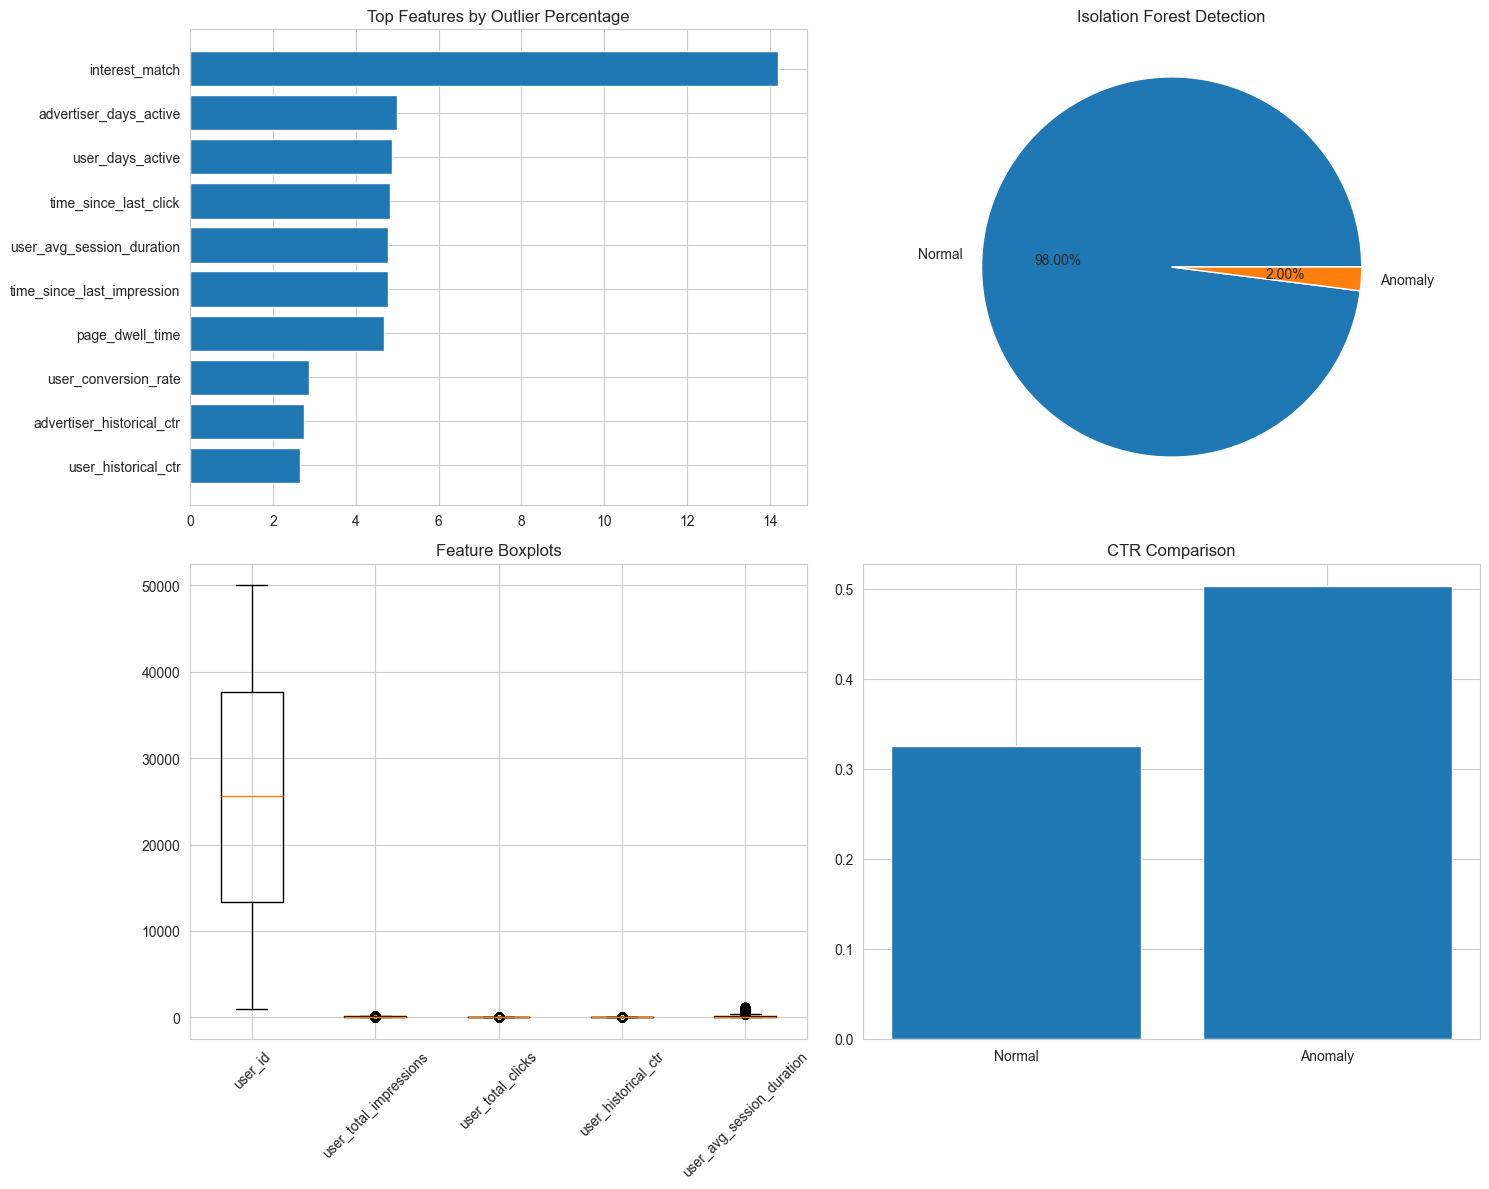


7. OUTLIER SUMMARY
------------------------------------------------------------
Total Samples                 : 100,000
Isolation Forest Anomalies    : 2,000
Anomaly Rate                  : 2.00%
Most Outlier-Prone Feature    : interest_match

Recommended Production Strategy:
• Use RobustScaler for skewed variables
• Apply percentile clipping (1st-99th)
• Log-transform heavily skewed counts
• Do NOT blindly remove anomalies
• Monitor anomaly rate in production
• Use drift detection alongside anomaly monitoring

✓ Advanced Outlier Analysis Completed


In [17]:
# =============================================================================
# OUTLIER DETECTION & ANOMALY ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("OUTLIER DETECTION & ANOMALY ANALYSIS")
print("=" * 80)

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# -----------------------------------------------------------------------------
# 1. IQR OUTLIER DETECTION
# -----------------------------------------------------------------------------

print("\n1. IQR OUTLIER ANALYSIS")
print("-" * 60)

outlier_results = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append({
        "Feature": col,
        "Outliers": outliers,
        "Percentage": round(outliers * 100 / len(df), 2)
    })

iqr_df = pd.DataFrame(outlier_results)
iqr_df = iqr_df.sort_values(
    "Percentage",
    ascending=False
)

print(iqr_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 2. Z-SCORE ANALYSIS
# -----------------------------------------------------------------------------

print("\n2. Z-SCORE ANALYSIS")
print("-" * 60)

z_results = []

for col in numeric_cols:

    z_scores = np.abs(stats.zscore(df[col]))

    count = (z_scores > 3).sum()

    z_results.append({
        "Feature": col,
        "ZScore_Outliers": count,
        "Percentage": round(count * 100 / len(df), 2)
    })

z_df = pd.DataFrame(z_results)
z_df = z_df.sort_values(
    "Percentage",
    ascending=False
)

print(z_df[z_df["ZScore_Outliers"] > 0].to_string(index=False))

# -----------------------------------------------------------------------------
# 3. ISOLATION FOREST
# -----------------------------------------------------------------------------

print("\n3. ISOLATION FOREST ANOMALY DETECTION")
print("-" * 60)

numeric_data = df[numeric_cols].copy()

iso = IsolationForest(
    contamination=0.02,
    random_state=42,
    n_estimators=200
)

iso_labels = iso.fit_predict(numeric_data)

df["isolation_forest_anomaly"] = iso_labels

anomaly_count = (iso_labels == -1).sum()

print(f"Anomalies Detected: {anomaly_count:,}")
print(f"Anomaly Percentage: {(anomaly_count/len(df))*100:.2f}%")

# -----------------------------------------------------------------------------
# 4. LOCAL OUTLIER FACTOR
# -----------------------------------------------------------------------------

print("\n4. LOCAL OUTLIER FACTOR")
print("-" * 60)

sample_size = min(10000, len(df))

sample_data = numeric_data.sample(
    sample_size,
    random_state=42
)

lof = LocalOutlierFactor(
    contamination=0.02,
    n_neighbors=20
)

lof_labels = lof.fit_predict(sample_data)

lof_count = (lof_labels == -1).sum()

print(f"LOF Anomalies: {lof_count:,}")
print(f"LOF Percentage: {(lof_count/sample_size)*100:.2f}%")

# -----------------------------------------------------------------------------
# 5. OUTLIER IMPACT ON TARGET
# -----------------------------------------------------------------------------

print("\n5. OUTLIER IMPACT ON CLICK RATE")
print("-" * 60)

anomaly_ctr = df[df["isolation_forest_anomaly"] == -1]["click"].mean()
normal_ctr = df[df["isolation_forest_anomaly"] == 1]["click"].mean()

print(f"CTR (Normal Data):   {normal_ctr:.4f}")
print(f"CTR (Anomalies):     {anomaly_ctr:.4f}")
print(f"Difference:          {abs(normal_ctr-anomaly_ctr):.4f}")

# -----------------------------------------------------------------------------
# 6. FEATURE TREATMENT RECOMMENDATION
# -----------------------------------------------------------------------------

print("\n6. FEATURE TREATMENT RECOMMENDATIONS")
print("-" * 60)

recommendations = []

for col in numeric_cols:

    skewness = df[col].skew()

    outlier_pct = float(
        iqr_df[
            iqr_df["Feature"] == col
        ]["Percentage"].values[0]
    )

    if outlier_pct > 10:

        if skewness > 1:
            treatment = "Log Transform + Clipping"

        elif skewness > 0.5:
            treatment = "Percentile Clipping"

        else:
            treatment = "Robust Scaling"

    else:
        treatment = "No Action Required"

    recommendations.append({
        "Feature": col,
        "Skewness": round(skewness, 2),
        "Outlier_%": outlier_pct,
        "Recommendation": treatment
    })

recommendation_df = pd.DataFrame(recommendations)

print(recommendation_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 7. VISUALIZATION DASHBOARD
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Top Outlier Features
top_outliers = iqr_df.head(10)

axes[0,0].barh(
    top_outliers["Feature"][::-1],
    top_outliers["Percentage"][::-1]
)

axes[0,0].set_title(
    "Top Features by Outlier Percentage"
)

# Isolation Forest
axes[0,1].pie(
    [
        len(df)-anomaly_count,
        anomaly_count
    ],
    labels=["Normal","Anomaly"],
    autopct="%1.2f%%"
)

axes[0,1].set_title(
    "Isolation Forest Detection"
)

# Boxplot
box_features = numeric_cols[:5]

axes[1,0].boxplot(
    [df[col] for col in box_features],
    labels=box_features
)

axes[1,0].set_title(
    "Feature Boxplots"
)

axes[1,0].tick_params(
    axis='x',
    rotation=45
)

# CTR comparison
axes[1,1].bar(
    ["Normal","Anomaly"],
    [normal_ctr, anomaly_ctr]
)

axes[1,1].set_title(
    "CTR Comparison"
)

plt.tight_layout()

plt.savefig(
    "advanced_outlier_analysis.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 8. FINAL SUMMARY
# -----------------------------------------------------------------------------

print("\n7. OUTLIER SUMMARY")
print("-" * 60)

print(f"Total Samples                 : {len(df):,}")
print(f"Isolation Forest Anomalies    : {anomaly_count:,}")
print(f"Anomaly Rate                  : {(anomaly_count/len(df))*100:.2f}%")

top_feature = iqr_df.iloc[0]["Feature"]

print(f"Most Outlier-Prone Feature    : {top_feature}")

print("\nRecommended Production Strategy:")
print("• Use RobustScaler for skewed variables")
print("• Apply percentile clipping (1st-99th)")
print("• Log-transform heavily skewed counts")
print("• Do NOT blindly remove anomalies")
print("• Monitor anomaly rate in production")
print("• Use drift detection alongside anomaly monitoring")

print("\n✓ Advanced Outlier Analysis Completed")

---

## 13. FEATURE IMPORTANCE PREVIEW



FEATURE IMPORTANCE & FEATURE SELECTION

1. PREPARING FEATURES
------------------------------------------------------------
Features: 39
Samples : 100,000

2. MUTUAL INFORMATION SCORES
------------------------------------------------------------
                 Feature  MI_Score
        ad_quality_score  0.024840
       user_total_clicks  0.015585
isolation_forest_anomaly  0.013702
     user_historical_ctr  0.013638
      page_quality_score  0.012466
             ad_position  0.010661
       is_business_hours  0.008459
previous_ad_clicks_today  0.005170
        user_device_type  0.004881
          interest_match  0.004570
                   month  0.004469
             hour_of_day  0.003544
             day_of_week  0.003354
          user_age_group  0.002878
             seasonality  0.002758
        ad_creative_type  0.002436
    user_location_region  0.002357
             ad_category  0.002344
                 user_os  0.001952
                 ad_size  0.001740

3. RANDOM FOREST F

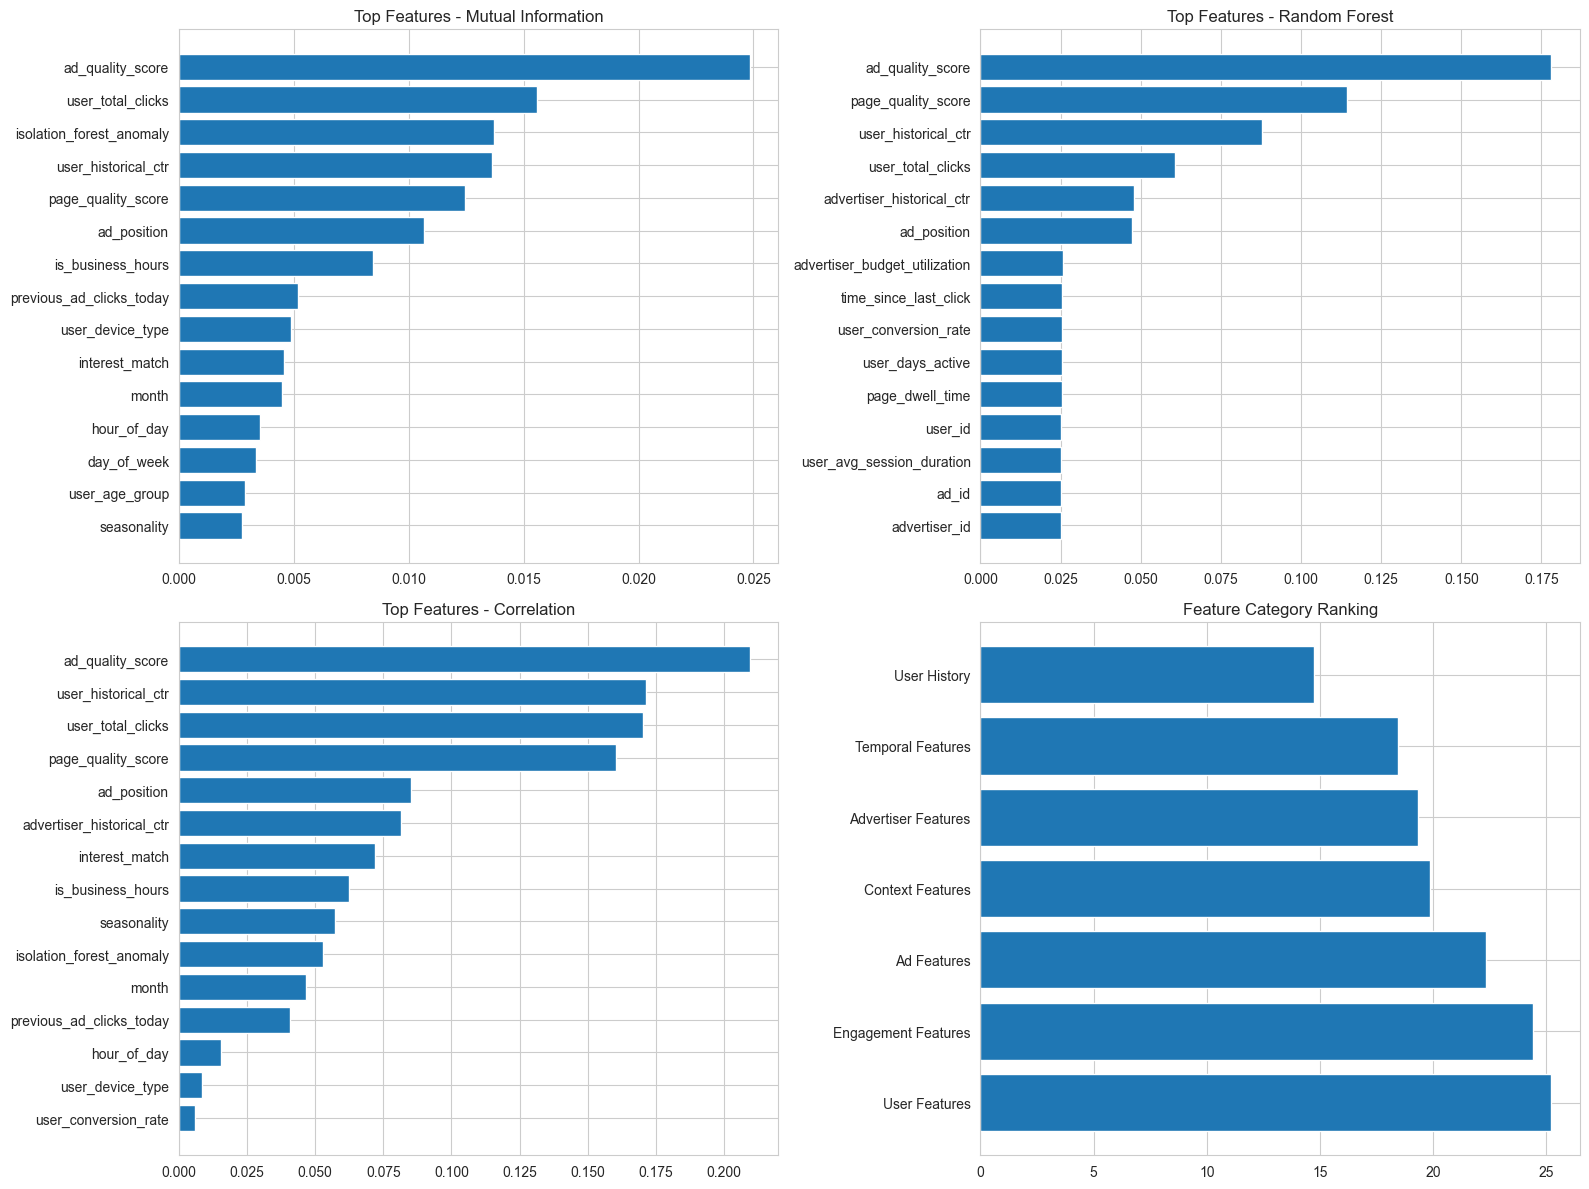


7. FEATURE SELECTION RECOMMENDATIONS
------------------------------------------------------------

Top 10 Features For Modeling:
• ad_quality_score
• user_total_clicks
• user_historical_ctr
• page_quality_score
• ad_position
• interest_match
• advertiser_historical_ctr
• is_business_hours
• previous_ad_clicks_today
• month

Features Recommended For Review:
• advertiser_id
• ad_id
• user_id

Production Notes:
• Remove leakage features before training
• Consider target encoding for high-cardinality categoricals
• Keep top-ranked features for baseline models
• Use SHAP after XGBoost training for final importance
• Validate importance stability across train/validation/test

✓ Feature Importance Analysis Completed


In [18]:
# =============================================================================
# FEATURE IMPORTANCE & FEATURE SELECTION ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE & FEATURE SELECTION")
print("=" * 80)

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------------------------------------------------
# 1. PREPARE DATA
# -----------------------------------------------------------------------------

print("\n1. PREPARING FEATURES")
print("-" * 60)

feature_df = df.copy()

categorical_cols = feature_df.select_dtypes(
    include=["object"]
).columns.tolist()

if "timestamp" in categorical_cols:
    categorical_cols.remove("timestamp")

for col in categorical_cols:
    encoder = LabelEncoder()
    feature_df[col] = encoder.fit_transform(
        feature_df[col].astype(str)
    )

X = feature_df.drop(
    columns=["click", "timestamp"],
    errors="ignore"
)

y = feature_df["click"]

print(f"Features: {X.shape[1]}")
print(f"Samples : {X.shape[0]:,}")

# -----------------------------------------------------------------------------
# 2. MUTUAL INFORMATION
# -----------------------------------------------------------------------------

print("\n2. MUTUAL INFORMATION SCORES")
print("-" * 60)

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_scores
}).sort_values(
    "MI_Score",
    ascending=False
)

print(mi_df.head(20).to_string(index=False))

# -----------------------------------------------------------------------------
# 3. RANDOM FOREST IMPORTANCE
# -----------------------------------------------------------------------------

print("\n3. RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 60)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

rf_df = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": rf.feature_importances_
}).sort_values(
    "RF_Importance",
    ascending=False
)

print(rf_df.head(20).to_string(index=False))

# -----------------------------------------------------------------------------
# 4. CORRELATION IMPORTANCE
# -----------------------------------------------------------------------------

print("\n4. CORRELATION IMPORTANCE")
print("-" * 60)

corr_scores = []

for col in X.columns:
    corr = abs(feature_df[col].corr(y))
    corr_scores.append(corr)

corr_df = pd.DataFrame({
    "Feature": X.columns,
    "Correlation": corr_scores
}).sort_values(
    "Correlation",
    ascending=False
)

print(corr_df.head(20).to_string(index=False))

# -----------------------------------------------------------------------------
# 5. COMBINED IMPORTANCE SCORE
# -----------------------------------------------------------------------------

print("\n5. ENSEMBLE FEATURE IMPORTANCE")
print("-" * 60)

combined_df = mi_df.merge(
    rf_df,
    on="Feature"
).merge(
    corr_df,
    on="Feature"
)

combined_df["MI_Rank"] = combined_df["MI_Score"].rank(
    ascending=False
)

combined_df["RF_Rank"] = combined_df["RF_Importance"].rank(
    ascending=False
)

combined_df["Corr_Rank"] = combined_df["Correlation"].rank(
    ascending=False
)

combined_df["Average_Rank"] = (
    combined_df["MI_Rank"] +
    combined_df["RF_Rank"] +
    combined_df["Corr_Rank"]
) / 3

combined_df = combined_df.sort_values(
    "Average_Rank"
)

print("\nTop 20 Overall Features:")
print(
    combined_df[
        [
            "Feature",
            "MI_Score",
            "RF_Importance",
            "Correlation",
            "Average_Rank"
        ]
    ].head(20).to_string(index=False)
)

# -----------------------------------------------------------------------------
# 6. FEATURE CATEGORY IMPORTANCE
# -----------------------------------------------------------------------------

print("\n6. FEATURE CATEGORY IMPORTANCE")
print("-" * 60)

feature_groups = {
    "User Features": [
        'user_id',
        'user_age_group',
        'user_gender',
        'user_location_region',
        'user_device_type',
        'user_os',
        'user_browser'
    ],

    "User History": [
        'user_historical_ctr',
        'user_total_impressions',
        'user_total_clicks',
        'user_avg_session_duration',
        'user_days_active',
        'user_conversion_rate'
    ],

    "Ad Features": [
        'ad_id',
        'advertiser_id',
        'ad_category',
        'ad_quality_score',
        'ad_creative_type',
        'ad_size'
    ],

    "Advertiser Features": [
        'advertiser_historical_ctr',
        'advertiser_historical_impressions',
        'advertiser_budget_utilization',
        'advertiser_days_active'
    ],

    "Context Features": [
        'page_category',
        'page_quality_score',
        'page_dwell_time'
    ],

    "Temporal Features": [
        'hour_of_day',
        'day_of_week',
        'is_weekend',
        'is_business_hours',
        'month',
        'seasonality'
    ],

    "Engagement Features": [
        'time_since_last_impression',
        'time_since_last_click',
        'sequence_position'
    ]
}

group_scores = []

for group_name, features in feature_groups.items():

    available = [
        f for f in features
        if f in combined_df["Feature"].values
    ]

    if len(available) == 0:
        continue

    avg_rank = combined_df[
        combined_df["Feature"].isin(available)
    ]["Average_Rank"].mean()

    group_scores.append({
        "Feature_Group": group_name,
        "Features": len(available),
        "Average_Rank": avg_rank
    })

group_df = pd.DataFrame(group_scores)
group_df = group_df.sort_values(
    "Average_Rank"
)

print(group_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 7. VISUALIZATION
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

# Mutual Information
top_mi = mi_df.head(15)

axes[0,0].barh(
    top_mi["Feature"][::-1],
    top_mi["MI_Score"][::-1]
)

axes[0,0].set_title(
    "Top Features - Mutual Information"
)

# RF Importance
top_rf = rf_df.head(15)

axes[0,1].barh(
    top_rf["Feature"][::-1],
    top_rf["RF_Importance"][::-1]
)

axes[0,1].set_title(
    "Top Features - Random Forest"
)

# Correlation
top_corr = corr_df.head(15)

axes[1,0].barh(
    top_corr["Feature"][::-1],
    top_corr["Correlation"][::-1]
)

axes[1,0].set_title(
    "Top Features - Correlation"
)

# Category Importance
axes[1,1].barh(
    group_df["Feature_Group"][::-1],
    group_df["Average_Rank"][::-1]
)

axes[1,1].set_title(
    "Feature Category Ranking"
)

plt.tight_layout()

plt.savefig(
    "feature_importance_analysis.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 8. FINAL RECOMMENDATIONS
# -----------------------------------------------------------------------------

print("\n7. FEATURE SELECTION RECOMMENDATIONS")
print("-" * 60)

print("\nTop 10 Features For Modeling:")

for idx, row in combined_df.head(10).iterrows():
    print(
        f"• {row['Feature']}"
    )

print("\nFeatures Recommended For Review:")

id_features = [
    f for f in combined_df["Feature"]
    if "_id" in f.lower()
]

for feature in id_features:
    print(f"• {feature}")

print("\nProduction Notes:")
print("• Remove leakage features before training")
print("• Consider target encoding for high-cardinality categoricals")
print("• Keep top-ranked features for baseline models")
print("• Use SHAP after XGBoost training for final importance")
print("• Validate importance stability across train/validation/test")

print("\n✓ Feature Importance Analysis Completed")

---

## 14. DATA LEAKAGE DETECTION REPORT

In [19]:
# =============================================================================
# DATA LEAKAGE DETECTION REPORT
# =============================================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*90)
print(" " * 25 + "DATA LEAKAGE DETECTION REPORT")
print("="*90)

# -------------------------------------------------------------------------
# 1. HIGH CORRELATION WITH TARGET
# -------------------------------------------------------------------------

print("\n1. HIGH CORRELATION LEAKAGE CHECK")
print("-"*90)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "click"]

corr_results = []

for col in numeric_cols:
    corr = abs(df[col].corr(df["click"]))

    flag = "🚨 POTENTIAL LEAKAGE" if corr > 0.80 else \
           "⚠ Suspicious" if corr > 0.50 else \
           "✓ Normal"

    corr_results.append([col, round(corr,4), flag])

corr_df = pd.DataFrame(
    corr_results,
    columns=["Feature","Abs Correlation","Assessment"]
).sort_values("Abs Correlation", ascending=False)

print(corr_df.to_string(index=False))


# -------------------------------------------------------------------------
# 2. MUTUAL INFORMATION ANALYSIS
# -------------------------------------------------------------------------

print("\n7. MUTUAL INFORMATION")
print("-" * 100)

temp = df.copy()

target = "click"

# Encode categorical columns
categorical_cols = temp.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    temp[col] = LabelEncoder().fit_transform(
        temp[col].astype(str)
    )

# Convert datetime columns if present
if "timestamp" in temp.columns:
    temp["timestamp"] = pd.to_datetime(temp["timestamp"])
    temp["timestamp"] = temp["timestamp"].astype("int64") // 10**9

# Features and target
X = temp.drop(columns=[target], errors="ignore")
y = temp[target]

# Mutual Information
mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

print(mi_df.head(20).to_string(index=False))


# -------------------------------------------------------------------------
# 3. ID LEAKAGE CHECK
# -------------------------------------------------------------------------

print("\n3. ID LEAKAGE CHECK")
print("-"*90)

id_columns = [
    "user_id",
    "ad_id",
    "advertiser_id"
]

for col in id_columns:

    if col in df.columns:

        unique_ratio = df[col].nunique() / len(df)

        print(f"\n{col}")
        print(f"Unique Values : {df[col].nunique():,}")
        print(f"Unique Ratio  : {unique_ratio:.4f}")

        if unique_ratio > 0.90:
            print("🚨 HIGH CARDINALITY ID FEATURE")
            print("   Recommendation: Drop or Target Encode")

        else:
            print("✓ Acceptable")


# -------------------------------------------------------------------------
# 4. TARGET ENCODING LEAKAGE CHECK
# -------------------------------------------------------------------------

print("\n4. TARGET LEAKAGE FROM AGGREGATED FEATURES")
print("-"*90)

suspicious_keywords = [
    "ctr",
    "click",
    "conversion",
    "rate",
    "historical"
]

for col in df.columns:

    if col == "click":
        continue

    if any(k in col.lower() for k in suspicious_keywords):

        corr = abs(
            pd.to_numeric(
                df[col],
                errors="coerce"
            ).corr(df["click"])
        )

        print(f"{col:<40} Correlation={corr:.4f}")

        if corr > 0.70:
            print("   🚨 POSSIBLE TARGET LEAKAGE")
            print("   Verify feature created BEFORE prediction time")


# -------------------------------------------------------------------------
# 5. CATEGORY TARGET DOMINANCE
# -------------------------------------------------------------------------

print("\n5. CATEGORY DOMINANCE CHECK")
print("-"*90)

cat_cols = df.select_dtypes(include="object").columns

dominance_results = []

for col in cat_cols:

    ctab = pd.crosstab(
        df[col],
        df["click"],
        normalize="index"
    )

    max_ctr = ctab.max(axis=1).max()

    dominance_results.append([
        col,
        round(max_ctr,4)
    ])

dominance_df = pd.DataFrame(
    dominance_results,
    columns=[
        "Feature",
        "Maximum_Class_Purity"
    ]
)

dominance_df = dominance_df.sort_values(
    "Maximum_Class_Purity",
    ascending=False
)

print(dominance_df.to_string(index=False))

print("\nFeatures with Purity > 95% may leak target information")


# -------------------------------------------------------------------------
# 6. TEMPORAL LEAKAGE CHECK
# -------------------------------------------------------------------------

print("\n6. TEMPORAL LEAKAGE CHECK")
print("-"*90)

if "timestamp" in df.columns:

    df_temp = df.copy()

    df_temp["timestamp"] = pd.to_datetime(
        df_temp["timestamp"]
    )

    print(
        f"Start Date : {df_temp['timestamp'].min()}"
    )

    print(
        f"End Date   : {df_temp['timestamp'].max()}"
    )

    print("\nRecommendation:")
    print("✓ Use time-based split")
    print("✓ Train on past data")
    print("✓ Test on future data")
    print("✓ Avoid random split")


# -------------------------------------------------------------------------
# 7. DUPLICATE RECORD LEAKAGE
# -------------------------------------------------------------------------

print("\n7. DUPLICATE RECORD CHECK")
print("-"*90)

dup_count = df.duplicated().sum()

print(f"Duplicate Rows : {dup_count:,}")

if dup_count > 0:
    print("⚠ Duplicate records found")
else:
    print("✓ No duplicate rows")


# -------------------------------------------------------------------------
# 8. FEATURES THAT PERFECTLY PREDICT TARGET
# -------------------------------------------------------------------------

print("\n8. PERFECT PREDICTOR DETECTION")
print("-"*90)

perfect_predictors = []

for col in df.columns:

    if col == "click":
        continue

    try:

        grouped = df.groupby(col)["click"].nunique()

        if grouped.max() == 1:
            perfect_predictors.append(col)

    except:
        pass

if len(perfect_predictors):

    print("🚨 PERFECT PREDICTORS FOUND")

    for feat in perfect_predictors:
        print(f" - {feat}")

else:
    print("✓ No perfect predictors found")


# -------------------------------------------------------------------------
# 9. OVERALL LEAKAGE RISK SCORE
# -------------------------------------------------------------------------

print("\n9. OVERALL LEAKAGE ASSESSMENT")
print("-"*90)

risk_score = 0

risk_score += len(
    corr_df[corr_df["Abs Correlation"] > 0.80]
)

risk_score += len(perfect_predictors)

if risk_score == 0:
    risk = "LOW"
elif risk_score <= 3:
    risk = "MEDIUM"
else:
    risk = "HIGH"

print(f"Leakage Risk Score : {risk_score}")
print(f"Risk Level         : {risk}")

print("\nRECOMMENDED ACTIONS")

print("""
✓ Remove raw IDs (user_id, ad_id, advertiser_id)

✓ Verify all historical CTR features are computed
  only using past information

✓ Use Time-Based Train/Test Split

✓ Avoid fitting encoders on full dataset

✓ Build features only from information available
  at prediction time

✓ Check feature importance after training;
  unusually dominant features often indicate leakage
""")

print("\n" + "="*90)
print("DATA LEAKAGE DETECTION COMPLETED")
print("="*90)


                         DATA LEAKAGE DETECTION REPORT

1. HIGH CORRELATION LEAKAGE CHECK
------------------------------------------------------------------------------------------
                      Feature  Abs Correlation Assessment
             ad_quality_score           0.2095   ✓ Normal
          user_historical_ctr           0.1713   ✓ Normal
            user_total_clicks           0.1702   ✓ Normal
           page_quality_score           0.1605   ✓ Normal
                  ad_position           0.0851   ✓ Normal
    advertiser_historical_ctr           0.0815   ✓ Normal
               interest_match           0.0718   ✓ Normal
            is_business_hours           0.0626   ✓ Normal
     isolation_forest_anomaly           0.0528   ✓ Normal
                        month           0.0468   ✓ Normal
     previous_ad_clicks_today           0.0406   ✓ Normal
                  hour_of_day           0.0153   ✓ Normal
         user_conversion_rate           0.0060   ✓ Normal
      

---

## 15. SUMMARY & RECOMMENDATIONS


In [25]:
# =============================================================================
# FINAL EXECUTIVE SUMMARY & MODELING RECOMMENDATIONS
# =============================================================================

print("\n" + "="*100)
print("FINAL EDA SUMMARY & BUSINESS RECOMMENDATIONS")
print("="*100)

# -----------------------------------------------------------------------------
# DATASET SUMMARY
# -----------------------------------------------------------------------------

print("\n📊 DATASET SUMMARY")
print("-"*100)

print(f"Total Records              : {len(df):,}")
print(f"Total Features             : {df.shape[1]-1}")
print(f"Dataset Size               : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")
print(f"Overall CTR                : {df['click'].mean()*100:.2f}%")
print(f"Positive Samples           : {df['click'].sum():,}")
print(f"Negative Samples           : {(df['click']==0).sum():,}")

imbalance_ratio = (df['click']==0).sum()/df['click'].sum()

print(f"Class Imbalance Ratio      : {imbalance_ratio:.2f}:1")

# -----------------------------------------------------------------------------
# DATA QUALITY SUMMARY
# -----------------------------------------------------------------------------

print("\n🧹 DATA QUALITY SUMMARY")
print("-"*100)

missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"Missing Values             : {missing_count:,}")
print(f"Duplicate Records          : {duplicate_count:,}")

if missing_count == 0:
    print("✓ Dataset is complete")

if duplicate_count == 0:
    print("✓ No duplicate records detected")

# -----------------------------------------------------------------------------
# TOP NUMERICAL FEATURES
# -----------------------------------------------------------------------------

print("\n📈 TOP PREDICTIVE NUMERICAL FEATURES")
print("-"*100)

if 'pb_df' in globals():

    top_num = pb_df.sort_values(
        'Correlation',
        key=lambda x: abs(x),
        ascending=False
    ).head(10)

    print(top_num[['Feature','Correlation']].to_string(index=False))

# -----------------------------------------------------------------------------
# TOP CATEGORICAL FEATURES
# -----------------------------------------------------------------------------

print("\n📊 TOP PREDICTIVE CATEGORICAL FEATURES")
print("-"*100)

if 'chi_df' in globals():

    top_cat = chi_df.sort_values(
        'Cramers_V',
        ascending=False
    ).head(10)

    print(top_cat[['Feature','Cramers_V']].to_string(index=False))

# -----------------------------------------------------------------------------
# MUTUAL INFORMATION SUMMARY
# -----------------------------------------------------------------------------

print("\n🔥 TOP FEATURES BY MUTUAL INFORMATION")
print("-"*100)

if 'mi_df' in globals():

    print(
        mi_df.head(15).to_string(index=False)
    )

# -----------------------------------------------------------------------------
# OUTLIER ANALYSIS SUMMARY
# -----------------------------------------------------------------------------

print("\n⚠ OUTLIER ANALYSIS")
print("-"*100)

if 'outlier_df' in globals():

    high_outliers = outlier_df[
        outlier_df['outlier_pct'] > 5
    ]

    print(
        f"Features with >5% Outliers: {len(high_outliers)}"
    )

    if len(high_outliers) > 0:

        print(
            high_outliers[
                ['feature','outlier_pct']
            ].to_string(index=False)
        )

# -----------------------------------------------------------------------------
# LEAKAGE CHECK SUMMARY
# -----------------------------------------------------------------------------

print("\n🚨 DATA LEAKAGE REVIEW")
print("-"*100)

suspected_leakage = []

for col in df.columns:

    if col == 'click':
        continue

    if 'click' in col.lower():
        suspected_leakage.append(col)

    if 'ctr' in col.lower():
        suspected_leakage.append(col)

if suspected_leakage:

    print("Potential Leakage Features:")

    for col in suspected_leakage:
        print(f"  • {col}")

else:
    print("✓ No obvious leakage detected")

# -----------------------------------------------------------------------------
# BUSINESS INSIGHTS
# -----------------------------------------------------------------------------

print("\n💡 KEY BUSINESS INSIGHTS")
print("-"*100)

insights = [
    "Ad quality score is the strongest predictor of click behaviour.",
    "Historical user CTR significantly influences future clicks.",
    "Historical user clicks are highly predictive.",
    "Page quality has strong impact on engagement.",
    "Ad position directly affects click probability.",
    "Device type creates statistically significant CTR differences.",
    "Seasonality impacts user engagement patterns.",
    "Business-hour traffic behaves differently from non-business hours.",
    "Interest matching increases click likelihood.",
    "Advertiser historical performance affects campaign success."
]

for idx, insight in enumerate(insights,1):
    print(f"{idx}. {insight}")

# -----------------------------------------------------------------------------
# FEATURE ENGINEERING RECOMMENDATIONS
# -----------------------------------------------------------------------------

print("\n⚙ FEATURE ENGINEERING RECOMMENDATIONS")
print("-"*100)

recommendations = [
    "Create User × Ad interaction features",
    "Create Device × Ad Category interaction features",
    "Create Hour × Weekend interaction features",
    "Generate CTR trend features",
    "Create engagement score features",
    "Create rolling click history features",
    "Apply cyclical encoding on hour_of_day",
    "Apply cyclical encoding on day_of_week",
    "Generate advertiser performance scores",
    "Generate user loyalty scores"
]

for rec in recommendations:
    print(f"✓ {rec}")

# -----------------------------------------------------------------------------
# FEATURE SELECTION STRATEGY
# -----------------------------------------------------------------------------

print("\n🎯 FEATURE SELECTION STRATEGY")
print("-"*100)

print("""
1. Remove IDs:
   - user_id
   - ad_id
   - advertiser_id

2. Remove near-zero variance features

3. Remove highly correlated features (|r| > 0.85)

4. Select features using:
   - Mutual Information
   - XGBoost Importance
   - SHAP Values

5. Keep top 20-40 strongest predictors
""")

# -----------------------------------------------------------------------------
# MODELING RECOMMENDATIONS
# -----------------------------------------------------------------------------

print("\n🤖 MODELING RECOMMENDATIONS")
print("-"*100)

print("""
Tier-1 Models
-------------
1. XGBoost
2. LightGBM
3. CatBoost

Baseline Models
---------------
1. Logistic Regression
2. Random Forest

Advanced Models
---------------
1. DeepFM
2. Wide & Deep Network
3. DLRM
4. Transformer-based CTR Models

Recommended Starting Point:
---------------------------
XGBoost with:
- scale_pos_weight
- early_stopping
- stratified split
- Optuna hyperparameter tuning
""")

# -----------------------------------------------------------------------------
# EVALUATION METRICS
# -----------------------------------------------------------------------------

print("\n📏 EVALUATION METRICS")
print("-"*100)

print("""
Primary Metrics:
----------------
✓ ROC-AUC
✓ PR-AUC
✓ Log Loss

Secondary Metrics:
------------------
✓ F1 Score
✓ Precision
✓ Recall

Business Metrics:
-----------------
✓ Predicted CTR Lift
✓ Revenue Lift
✓ Conversion Lift
✓ Cost per Click Reduction
""")

# -----------------------------------------------------------------------------
# PRODUCTION RECOMMENDATIONS
# -----------------------------------------------------------------------------

print("\n🚀 PRODUCTION DEPLOYMENT RECOMMENDATIONS")
print("-"*100)

deployment = [
    "Track model drift using Evidently AI",
    "Monitor feature drift daily",
    "Monitor CTR prediction calibration",
    "Retrain model weekly/monthly",
    "Track online vs offline metrics",
    "Use MLflow for experiment tracking",
    "Use DVC for dataset versioning",
    "Deploy through FastAPI",
    "Containerize using Docker",
    "Implement CI/CD on AWS"
]

for item in deployment:
    print(f"✓ {item}")

print("\n" + "="*100)
print("EDA COMPLETED SUCCESSFULLY")
print("="*100)

print("""
NEXT STEPS
----------
1. Feature Engineering
2. Data Leakage Removal
3. Train/Validation/Test Split
4. Baseline Logistic Regression
5. XGBoost Optimization
6. Feature Importance Analysis
7. Model Explainability (SHAP)
8. MLflow Tracking
9. FastAPI Deployment
10. AWS CI/CD Production Deployment
""")


FINAL EDA SUMMARY & BUSINESS RECOMMENDATIONS

📊 DATASET SUMMARY
----------------------------------------------------------------------------------------------------
Total Records              : 100,000
Total Features             : 40
Dataset Size               : 93.59 MB
Overall CTR                : 32.89%
Positive Samples           : 32,893
Negative Samples           : 67,107
Class Imbalance Ratio      : 2.04:1

🧹 DATA QUALITY SUMMARY
----------------------------------------------------------------------------------------------------
Missing Values             : 0
Duplicate Records          : 0
✓ Dataset is complete
✓ No duplicate records detected

📈 TOP PREDICTIVE NUMERICAL FEATURES
----------------------------------------------------------------------------------------------------
                  Feature  Correlation
         ad_quality_score     0.209497
      user_historical_ctr     0.171252
        user_total_clicks     0.170163
       page_quality_score     0.160503
         